In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import time
import types
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.decomposition import PCA as SklearnPCA
from statsmodels.tsa.api import VAR

warnings.filterwarnings('ignore')

from meteor import Cmip6MeteorDataGetter, geo_data_utils
from meteor.noise_model.ae_varx import AEVARXNoiseModel
from meteor.noise_model.noise_model_data_utils import build_exog_matrix, create_harmonic_features

from fys9429.ae_experiment_runner import (
    make_configurable_ae,
    ExperimentRegistry,
    run_ae_experiment,
    run_sweep,
    compute_reconstruction_metrics,
    compute_latent_diagnostics,
    compute_varx_diagnostics,
    compute_stochastic_rollout_stability,
)

print("✅ Imports complete")

✅ Imports complete


## Configuration

In [3]:
NOTEBOOK_VAR  = "pr"       # change to 'pr' to repeat for precipitation
MODEL         = 'NorESM2-MM'
VARIABLES     = [NOTEBOOK_VAR, "tas"]
SCENARIO      = 'ssp245'
LAG_ORDER     = 2
USE_EXOG      = "temp_only"
SEED          = 42
np.random.seed(SEED)

notebook_dir = Path.cwd()
SCRATCH_DIR  = Path("/scratch/johannlf/ae_sweep") / NOTEBOOK_VAR
RESULTS_DIR  = SCRATCH_DIR / "results"
FIGURE_DIR   = notebook_dir / "figures" / "ae_varx" / NOTEBOOK_VAR
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Variable  : {NOTEBOOK_VAR}")
print(f"Scratch   : {SCRATCH_DIR}")
print(f"Results   : {RESULTS_DIR}")
print(f"Figures   : {FIGURE_DIR}")


Variable  : pr
Scratch   : /scratch/johannlf/ae_sweep/pr
Results   : /scratch/johannlf/ae_sweep/pr/results
Figures   : /uio/kant/geo-geofag-u1/johannlf/FYS9429/investigations/monthly_output/figures/ae_varx/pr


## Load CMIP6 data

In [4]:
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "historical", "ssp245", "ssp126", "ssp585"],
    flds=VARIABLES,
    dbe=['CMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP', 'ScenarioMIP'],
    enable_cache=True,
)
cmip6_data_raw = data_getter.make_meteor_training_data_composite(
    ["historical", SCENARIO], MODEL, monthly=True
)
picontrol_data = data_getter.make_meteor_training_data("piControl", MODEL, monthly=True)

picontrol_global  = geo_data_utils.global_mean(picontrol_data[NOTEBOOK_VAR])
picontrol_baseline = picontrol_global.mean()

print(f"CMIP6 {NOTEBOOK_VAR} shape : {cmip6_data_raw[NOTEBOOK_VAR].shape}")
print(f"piControl baseline  : {float(picontrol_baseline):.3e} {cmip6_data_raw[NOTEBOOK_VAR].units}")

CMIP6 pr shape : (1, 3012, 192, 288)
piControl baseline  : 3.296e-05 kg m-2 s-1


## Prepare AE training data

In [5]:
X_ae_mlp = AEVARXNoiseModel.prepare_training_data_for_AE(
    monthly_data=cmip6_data_raw,
    variable_name=NOTEBOOK_VAR,
    picontrol_baseline=picontrol_baseline,
    data_type="mlp",
)
X_ae_conv = AEVARXNoiseModel.prepare_training_data_for_AE(
    monthly_data=cmip6_data_raw,
    variable_name=NOTEBOOK_VAR,
    picontrol_baseline=picontrol_baseline,
    data_type="conv",
)

lats = cmip6_data_raw[NOTEBOOK_VAR].lat.values
lons = cmip6_data_raw[NOTEBOOK_VAR].lon.values

# Smoothed global *temperature* anomaly (VARX exogenous forcing).
# Use the tas piControl baseline — not the pr baseline.
da_tas = cmip6_data_raw["tas"]
if 'ens' in da_tas.dims:
    da_tas = da_tas.mean(dim='ens')
picontrol_tas_baseline = float(geo_data_utils.global_mean(picontrol_data["tas"]).mean())
t_globm = (geo_data_utils.global_mean(da_tas) - picontrol_tas_baseline).values
t_glob  = pd.Series(t_globm).rolling(60, center=True, min_periods=1).mean().values

# Global-std normalisation — single scalar preserves spatial structure and
# brings pr (O(1e-5) kg/m²/s) to O(1), preventing vanishing MSE gradients.
# Store X_ae_scale so physical units can be recovered: physical = normalised * X_ae_scale
X_ae_scale = float(X_ae_mlp.std())
X_ae_mlp   = (X_ae_mlp  / X_ae_scale).astype(np.float32)
X_ae_conv  = (X_ae_conv / X_ae_scale).astype(np.float32)

print(f"X_ae_mlp  : {X_ae_mlp.shape}  (T, n_lat*n_lon)")
print(f"X_ae_conv : {X_ae_conv.shape}")
print(f"t_glob    : {t_glob.shape}  [{t_glob.min():.2f}, {t_glob.max():.2f}] K")
print(f"X_ae_scale: {X_ae_scale:.3e}  (multiply normalised values × this to recover {NOTEBOOK_VAR} units)")


X_ae_mlp  : (3012, 55296)  (T, n_lat*n_lon)
X_ae_conv : (3012, 1, 192, 288)
t_glob    : (3012,)  [-0.24, 2.51] K
X_ae_scale: 1.826e-05  (multiply normalised values × this to recover pr units)


---
## Phase 1 — PCA Baseline

Run sklearn PCA for `n_modes ∈ {16, 32, 64, 128}`, fit a VARX model on the resulting latent codes, and compute the same set of metrics that `run_ae_experiment` produces.

In [6]:
def run_pca_experiment(
    n_modes: int,
    X_ae_mlp: np.ndarray,
    lats: np.ndarray,
    t_glob: np.ndarray,
    lag_order: int = 2,
    use_exog: str = "temp_only",
    verbose: bool = True,
) -> dict:
    """Run a single PCA-VARX experiment, returning the same metrics dict as run_ae_experiment."""
    t0 = time.perf_counter()

    # --- PCA encode / decode ---
    pca = SklearnPCA(n_components=n_modes, random_state=SEED)
    pcs   = pca.fit_transform(X_ae_mlp)          # (T, n_modes)
    X_recon = pca.inverse_transform(pcs)          # (T, n_lat*n_lon)
    train_time = time.perf_counter() - t0

    recon_metrics  = compute_reconstruction_metrics(X_ae_mlp, X_recon, lats)
    latent_metrics = compute_latent_diagnostics(pcs)

    varx_metrics   = dict(spectral_radius=np.nan, aic=np.nan, bic=np.nan,
                          ljungbox_mean_pval=np.nan, ks_normality_mean_pval=np.nan)
    rollout_metrics = dict(nan_fraction=np.nan, inf_fraction=np.nan,
                           variance_drift_ratio=np.nan, mean_drift_abs=np.nan)
    try:
        n_time = len(t_glob)
        X_exog = build_exog_matrix(
            create_harmonic_features(np.arange(n_time), t_glob), use_exog
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            varx_results = VAR(endog=pcs, exog=X_exog).fit(lag_order)

        nm = types.SimpleNamespace(
            varx_results=varx_results,
            lag_order=lag_order,
            use_exog=use_exog,
            noise_pc_distribution="normal",
            t_df=None,
        )
        nm._generate_stochastic_pcs = types.MethodType(
            AEVARXNoiseModel._generate_stochastic_pcs, nm
        )

        varx_metrics   = compute_varx_diagnostics(nm)
        rollout_metrics = compute_stochastic_rollout_stability(nm, t_glob)
    except Exception as e:
        if verbose:
            print(f"  PCA n_modes={n_modes} VARX error: {e}")

    # Approximate parameter count: n_modes components × input_dim (loadings matrix)
    n_params = int(n_modes * X_ae_mlp.shape[1])

    return {
        "arch_type": "pca",
        "latent_dim": n_modes,
        "n_modes": n_modes,
        "n_params": n_params,
        "train_time_s": train_time,
        **recon_metrics,
        **latent_metrics,
        **varx_metrics,
        **rollout_metrics,
    }

In [7]:
PCA_N_MODES = [16, 32, 40, 64, 128]

pca_records = []
for n_modes in PCA_N_MODES:
    print(f"PCA n_modes={n_modes} ...", end=" ", flush=True)
    rec = run_pca_experiment(
        n_modes, X_ae_mlp, lats, t_glob,
        lag_order=LAG_ORDER, use_exog="none", verbose=True,
    )
    pca_records.append(rec)
    print(f"RMSE={rec['rmse']:.4f}  SR={rec.get('spectral_radius', float('nan')):.4f}")

df_pca = pd.DataFrame(pca_records)
df_pca.to_parquet(SCRATCH_DIR / f"pca_results_{NOTEBOOK_VAR}.parquet", index=False)
print(f"\n✅ PCA results saved → {SCRATCH_DIR / f'pca_results_{NOTEBOOK_VAR}.parquet'}")
df_pca[["n_modes", "rmse", "explained_variance", "spectral_radius",
        "variance_drift_ratio", "nan_fraction"]]

PCA n_modes=16 ... RMSE=0.9771  SR=0.8812
PCA n_modes=32 ... RMSE=0.9023  SR=0.8994
PCA n_modes=40 ... RMSE=0.8740  SR=0.9030
PCA n_modes=64 ... RMSE=0.8105  SR=0.9172
PCA n_modes=128 ... RMSE=0.6993  SR=0.9419

✅ PCA results saved → /scratch/johannlf/ae_sweep/pr/pca_results_pr.parquet


,n_modes,rmse,explained_variance,spectral_radius,variance_drift_ratio,nan_fraction
0,16,0.977083,0.314886,0.881173,1.709292,0.0
1,32,0.902326,0.410440,0.899447,1.492323,0.0
2,40,0.874012,0.444997,0.902960,1.464190,0.0
3,64,0.810491,0.521409,0.917154,1.323705,0.0
4,128,0.699261,0.640236,0.941866,1.445768,0.0


---
## Phase 1b — Standard AE Baseline

Run a **single reference architecture** (`hidden=[1024, 512]`, `dropout=0.1`, `use_residual=True`) across
the same latent dimensions as the PCA sweep.  
This lets us sanity-check all collected diagnostics and see whether the AE is competitive *before*
committing to the full 48-run sweep.


In [8]:
REFERENCE_ARCH = dict(
    hidden       = [512, 256],
    dropout      = 0.1,
    use_residual = True,
    epochs       = 50,
    device       = "auto",
)

ae_ref_records = []
for ld in [16, 32, 64, 128]:
    config = {"latent_dim": ld, **REFERENCE_ARCH}
    print(f"AE ref  latent={ld} ...", end=" ", flush=True)
    metrics = run_ae_experiment(
        config_dict    = config,
        X_ae_mlp       = X_ae_mlp,
        X_ae_conv      = X_ae_conv,
        lats           = lats,
        lons           = lons,
        t_glob         = t_glob,
        lag_order      = LAG_ORDER,
        use_exog       = "none",
        checkpoint_dir = RESULTS_DIR / "checkpoints",
        verbose        = False,
    )
    print(
        f"RMSE={metrics['rmse']:.4f}  "
        f"EV={metrics['explained_variance']:.4f}  "
        f"SR={metrics.get('spectral_radius', float('nan')):.4f}  "
        f"VDR={metrics.get('variance_drift_ratio', float('nan')):.4f}"
    )
    ae_ref_records.append({"latent_dim": ld, **config, **metrics})

df_ae_ref = pd.DataFrame(ae_ref_records)


AE ref  latent=16 ... RMSE=0.7648  EV=0.5752  SR=0.8702  VDR=1.4291
AE ref  latent=32 ... RMSE=0.7246  EV=0.6175  SR=0.8856  VDR=1.2567
AE ref  latent=64 ... RMSE=0.7173  EV=0.6254  SR=0.8935  VDR=1.2830
AE ref  latent=128 ... RMSE=0.7162  EV=0.6265  SR=0.9117  VDR=0.0286


In [9]:
# ── Full diagnostics table ───────────────────────────────────────────────────
print("All collected metrics (reference AE):\n")
pd.set_option("display.max_rows", None)
df_ae_ref.T


All collected metrics (reference AE):



,0,1,2,3
latent_dim,16,32,64,128
hidden,"[512, 256]","[512, 256]","[512, 256]","[512, 256]"
dropout,0.1,0.1,0.1,0.1
use_residual,True,True,True,True
epochs,50,50,50,50
device,auto,auto,auto,auto
rmse,0.764764,0.724627,0.717333,0.716169
explained_variance,0.575192,0.617516,0.62541,0.626502
spatial_corr,0.754438,0.783985,0.789691,0.790166
arctic_rmse,0.24429,0.235796,0.235079,0.234351


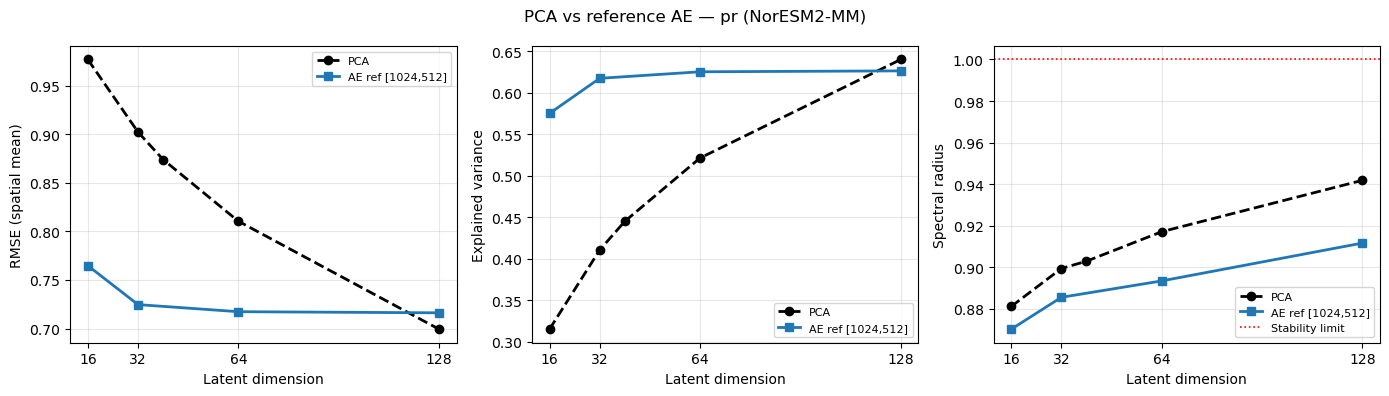

In [10]:
# ── Quick comparison: PCA vs reference AE ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_to_plot = [
    ("rmse",               "RMSE (spatial mean)",      False),
    ("explained_variance", "Explained variance",       False),
    ("spectral_radius",    "Spectral radius",          True),
]

for ax, (metric, ylabel, draw_boundary) in zip(axes, metrics_to_plot):
    ax.plot(df_pca["latent_dim"], df_pca[metric],
            "o--", color="black", linewidth=2, label="PCA")
    ax.plot(df_ae_ref["latent_dim"], df_ae_ref[metric],
            "s-", color="tab:blue", linewidth=2, label="AE ref [1024,512]")
    if draw_boundary:
        ax.axhline(1.0, color="red", linestyle=":", linewidth=1.2, label="Stability limit")
    ax.set_xlabel("Latent dimension")
    ax.set_ylabel(ylabel)
    ax.set_xticks([16, 32, 64, 128])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"PCA vs reference AE — {NOTEBOOK_VAR} ({MODEL})", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "phase1b_pca_vs_ae_ref.png", dpi=150)
plt.show()


In [11]:
import torch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from fys9429.ae_experiment_runner import ConfigurableMLP, ExperimentRegistry

PLOT_LD = 64   # latent dimension to visualise
n_lat, n_lon = len(lats), len(lons)

# PCA reconstruction (fast)
pca_plot   = SklearnPCA(n_components=PLOT_LD, random_state=SEED)
pcs_pca    = pca_plot.fit_transform(X_ae_mlp)
X_recon_pca = pca_plot.inverse_transform(pcs_pca)

# Load saved AE checkpoint
config_for_ckpt = {"latent_dim": PLOT_LD, **REFERENCE_ARCH}
cid      = ExperimentRegistry.__new__(ExperimentRegistry).config_id(config_for_ckpt)
ckpt     = RESULTS_DIR / "checkpoints" / f"ae_{cid}.pt"

ae_plot = ConfigurableMLP(
    input_dim    = X_ae_mlp.shape[1],
    latent_dim   = PLOT_LD,
    hidden       = tuple(REFERENCE_ARCH["hidden"]),
    dropout      = REFERENCE_ARCH["dropout"],
    use_residual = REFERENCE_ARCH["use_residual"],
)
ae_plot.load_state_dict(torch.load(ckpt, map_location="cpu", weights_only=True))
ae_plot.eval()
X_recon_ae = ae_plot.decode(ae_plot.encode(X_ae_mlp))

rmse_pca = np.sqrt(((X_recon_pca - X_ae_mlp)**2).mean(axis=0))
rmse_ae  = np.sqrt(((X_recon_ae  - X_ae_mlp)**2).mean(axis=0))

T_SAMPLE = 600   # example time step (~late historical period)
orig_map      = X_ae_mlp[T_SAMPLE].reshape(n_lat, n_lon)
recon_pca_map = X_recon_pca[T_SAMPLE].reshape(n_lat, n_lon)
recon_ae_map  = X_recon_ae[T_SAMPLE].reshape(n_lat, n_lon)

print(f'✅  X_recon_pca: {X_recon_pca.shape}  X_recon_ae: {X_recon_ae.shape}')
print(f'    Global mean RMSE — PCA: {rmse_pca.mean():.4f}   AE: {rmse_ae.mean():.4f}')


✅  X_recon_pca: (3012, 55296)  X_recon_ae: (3012, 55296)
    Global mean RMSE — PCA: 0.5711   AE: 0.5058


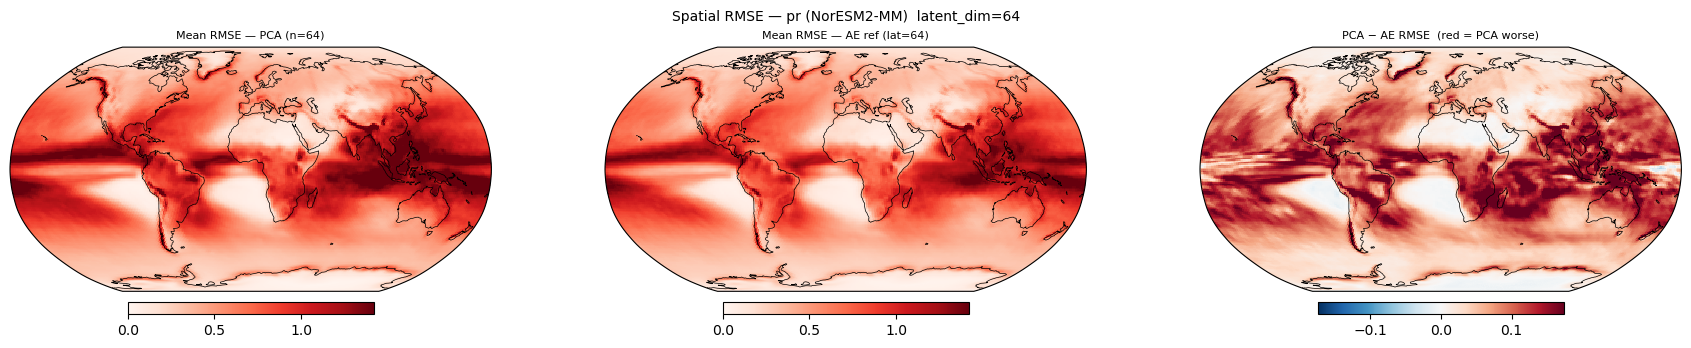

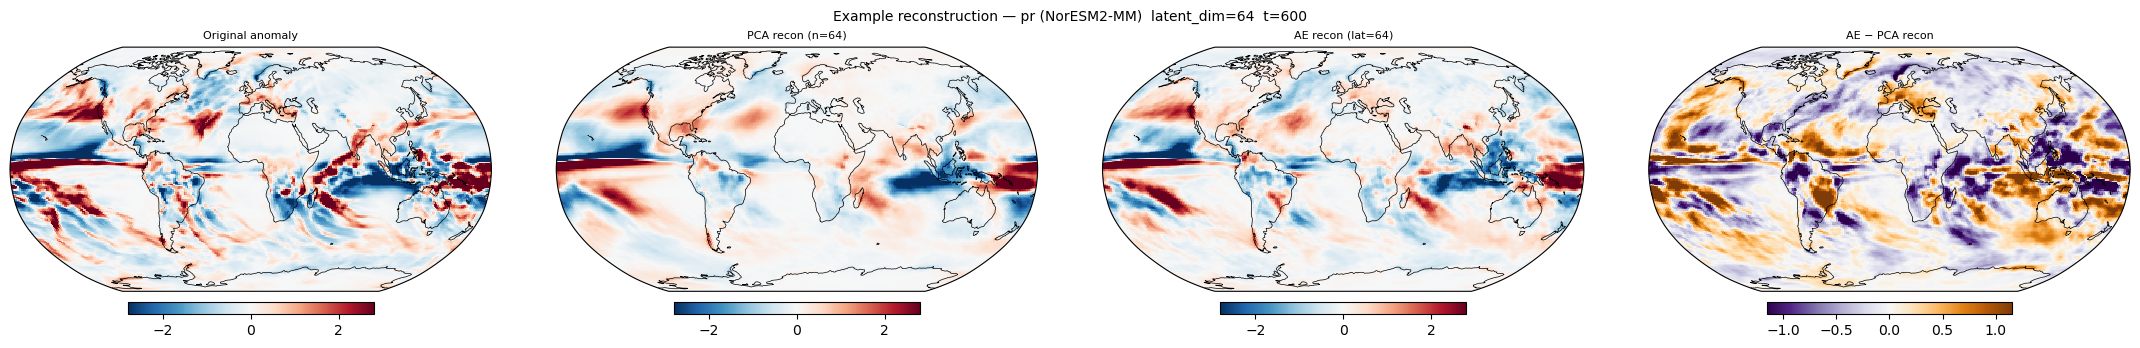

In [12]:
# ── Spatial RMSE maps ──────────────────────────────────────────────────────
def _mapax(ax, data, title, cmap, vmin, vmax):
    im = ax.pcolormesh(lons, lats, data.reshape(n_lat, n_lon), cmap=cmap,
                       vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=8)
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, fraction=0.046)

fig, axes = plt.subplots(1, 3, figsize=(18, 3.5),
                          subplot_kw={'projection': ccrs.Robinson()})
rmax = float(np.nanpercentile(rmse_pca, 97))
dmax = float(np.nanpercentile(np.abs(rmse_pca - rmse_ae), 97))
_mapax(axes[0], rmse_pca, f'Mean RMSE — PCA (n={PLOT_LD})',      'Reds',   0, rmax)
_mapax(axes[1], rmse_ae,  f'Mean RMSE — AE ref (lat={PLOT_LD})', 'Reds',   0, rmax)
_mapax(axes[2], rmse_pca - rmse_ae, 'PCA − AE RMSE  (red = PCA worse)', 'RdBu_r', -dmax, dmax)
fig.suptitle(f'Spatial RMSE — {NOTEBOOK_VAR} ({MODEL})  latent_dim={PLOT_LD}', fontsize=10)
fig.tight_layout()
fig.savefig(FIGURE_DIR / f'phase1b_rmse_maps_ld{PLOT_LD}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Example reconstruction ──────────────────────────────────────────────────
v = float(np.nanpercentile(np.abs(orig_map), 97))
dv = float(np.nanpercentile(np.abs(recon_ae_map - recon_pca_map), 97))

fig, axes = plt.subplots(1, 4, figsize=(22, 3.5),
                          subplot_kw={'projection': ccrs.Robinson()})
panels = [
    (orig_map,                       'Original anomaly',            'RdBu_r', -v,  v),
    (recon_pca_map,                  f'PCA recon (n={PLOT_LD})',    'RdBu_r', -v,  v),
    (recon_ae_map,                   f'AE recon (lat={PLOT_LD})',   'RdBu_r', -v,  v),
    (recon_ae_map - recon_pca_map,   'AE − PCA recon',              'PuOr_r', -dv, dv),
]
for ax, (data, title, cmap, lo, hi) in zip(axes, panels):
    _mapax(ax, data, title, cmap, lo, hi)
fig.suptitle(
    f'Example reconstruction — {NOTEBOOK_VAR} ({MODEL})  '
    f'latent_dim={PLOT_LD}  t={T_SAMPLE}', fontsize=10)
fig.tight_layout()
fig.savefig(FIGURE_DIR / f'phase1b_recon_example_ld{PLOT_LD}.png', dpi=150, bbox_inches='tight')
plt.show()


---
## AE Architecture Sweep

Grid: `latent_dim` × `hidden` × `dropout` × `use_residual` = 4 × 3 × 2 × 2 = **48 runs**.  
Completed configs are skipped via the `ExperimentRegistry` (checkpoint in `results/`).

In [13]:
sweep_grid = {
    "latent_dim":   [16, 32, 64, 128],
    "hidden":       [[512], [1024, 512], [1024, 512, 256]],
    "dropout":      [0.1, 0.3],
    "use_residual": [True, False],
    "epochs":       [100],
    "device":       ["auto"],
}

# Quick check: how many unique configs?
from itertools import product
keys   = list(sweep_grid.keys())
combos = list(product(*sweep_grid.values()))
print(f"Total configs: {len(combos)}")


Total configs: 48


In [14]:
df_ae = run_sweep(
    grid=sweep_grid,
    X_ae_mlp=X_ae_mlp,
    X_ae_conv=X_ae_conv,
    lats=lats,
    lons=lons,
    t_glob=t_glob,
    results_dir=SCRATCH_DIR,
    lag_order=LAG_ORDER,
    use_exog="none",
    skip_done=True,
    verbose=True,
)


[1/48] SKIP  {'latent_dim': 16, 'hidden': [512], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
[2/48] SKIP  {'latent_dim': 16, 'hidden': [512], 'dropout': 0.1, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
[3/48] SKIP  {'latent_dim': 16, 'hidden': [512], 'dropout': 0.3, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
[4/48] SKIP  {'latent_dim': 16, 'hidden': [512], 'dropout': 0.3, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
[5/48] SKIP  {'latent_dim': 16, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
[6/48] SKIP  {'latent_dim': 16, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
[7/48] SKIP  {'latent_dim': 16, 'hidden': [1024, 512], 'dropout': 0.3, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
[8/48] SKIP  {'latent_dim': 16, 'hidden': [1024, 512], 'dropout': 0.3, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
[9/48] SKIP 

---
## Comparison

Load saved results, merge PCA and AE tables, and produce comparison plots.

In [15]:

# ── Load results ────────────────────────────────────────────────────────────
df_pca_loaded = pd.read_parquet(SCRATCH_DIR / f"pca_results_{NOTEBOOK_VAR}.parquet")
df_ae_loaded  = pd.read_parquet(SCRATCH_DIR / "sweep_results.parquet")

# run_sweep() appends every call's results into the same registry (and parquet),
# so after later the parquet contains more rows than just the first sweep.
# Filter to first sweep only: those rows have nan's in the extra hyperparameters.
_second_sweep_extra = [c for c in ("activation", "optimizer", "loss", "lr", "weight_decay")
             if c in df_ae_loaded.columns]
if _second_sweep_extra:
    first_sweep_mask = df_ae_loaded[_second_sweep_extra].isna().all(axis=1)
    df_ae_loaded = df_ae_loaded[first_sweep_mask].copy()

# Tag each table
df_pca_loaded["arch_type"] = "pca"
df_ae_loaded["arch_type"]  = "ae"

# Harmonise column names for shared plotting
df_ae_loaded["n_modes"] = df_ae_loaded["latent_dim"]

# Create a readable architecture label
def _arch_label(row):
    if row["arch_type"] == "pca":
        return "PCA"
    hidden_str = "-".join(str(h) for h in row["hidden"])
    res = "R" if row["use_residual"] else "NR"
    return f"{hidden_str} ({res})"

df_ae_loaded["arch_label"] = df_ae_loaded.apply(_arch_label, axis=1)
df_pca_loaded["arch_label"] = "PCA"

print(f"PCA rows : {len(df_pca_loaded)}")
print(f"AE  rows : {len(df_ae_loaded)}  (First sweep only)")
print("\nAE columns:", list(df_ae_loaded.columns))


PCA rows : 5
AE  rows : 48  (First sweep only)

AE columns: ['latent_dim', 'hidden', 'dropout', 'use_residual', 'epochs', 'device', 'rmse', 'explained_variance', 'spatial_corr', 'arctic_rmse', 'sh_rmse', 'skew_mae', 'kurt_mae', 'effective_rank', 'mean_skew', 'mean_kurt', 'mean_acf_lag1', 'mean_acf_lag12', 'corr_matrix_offdiag_mean', 'spectral_radius', 'aic', 'bic', 'ljungbox_mean_pval', 'ks_normality_mean_pval', 'nan_fraction', 'inf_fraction', 'variance_drift_ratio', 'mean_drift_abs', 'train_time_s', 'run_id', 'timestamp', 'activation', 'optimizer', 'loss', 'lr', 'weight_decay', 'arch_type', 'n_modes', 'arch_label']


NameError: name 'pca_best' is not defined

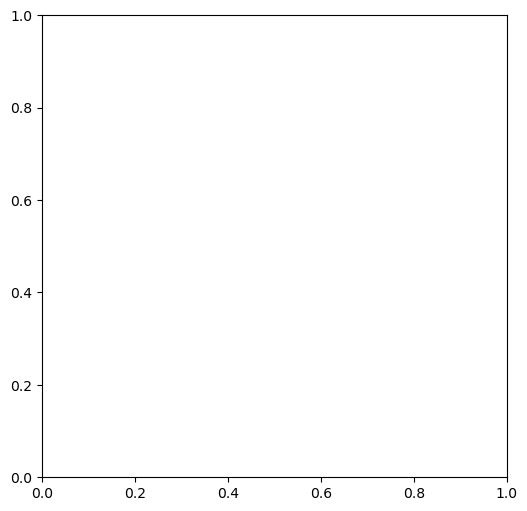

In [16]:
# ── AE vs PCA — matched latent_dim scatter ─────────────────────────
# For each latent_dim, find the best AE config and compare to PCA
best_per_dim = (
    df_ae_loaded
    .sort_values("rmse")
    .groupby("latent_dim", as_index=False)
    .first()
)

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in best_per_dim.iterrows():
    n = int(row["latent_dim"])
    pca_row = pca_best[pca_best["latent_dim"] == n]
    if pca_row.empty:
        continue
    pca_rmse = float(pca_row["rmse"].values[0])
    ae_rmse  = float(row["rmse"])
    ax.scatter(pca_rmse, ae_rmse, s=120, zorder=4)
    ax.annotate(f"dim={n}", (pca_rmse, ae_rmse), textcoords="offset points",
                xytext=(6, 4), fontsize=9)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="Equal performance")
ax.set_xlabel("PCA RMSE")
ax.set_ylabel("Best AE RMSE (same latent_dim)")
ax.set_title(f"AE vs PCA — {NOTEBOOK_VAR} ({MODEL})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

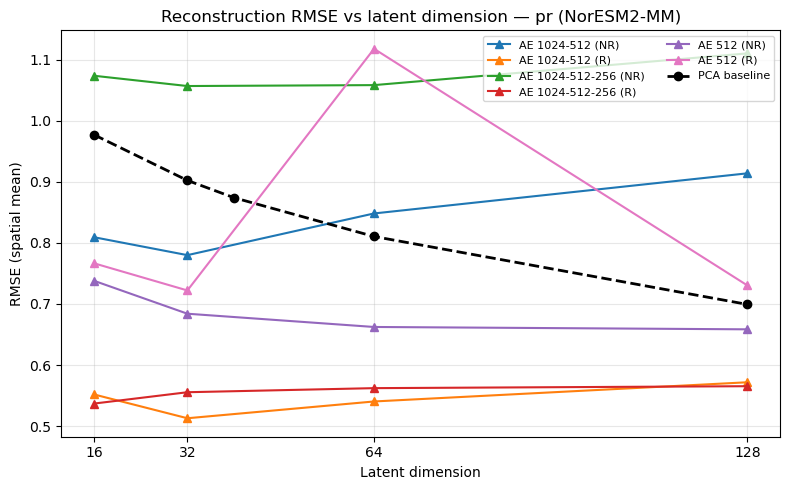

In [ ]:
# ── RMSE vs latent_dim (efficiency curve) ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

arch_labels = sorted(ae_best["arch_label"].unique())
colors      = plt.cm.tab10(np.linspace(0, 0.6, len(arch_labels)))

for col, arch in zip(colors, arch_labels):
    sub = ae_best[ae_best["arch_label"] == arch].sort_values("latent_dim")
    ax.plot(sub["latent_dim"], sub["rmse"], marker="^", color=col,
            label=f"AE {arch}", linewidth=1.5)

# PCA baseline
ax.plot(pca_best["latent_dim"], pca_best["rmse"], "o--",
        color="black", label="PCA baseline", linewidth=2)

ax.set_xlabel("Latent dimension")
ax.set_ylabel("RMSE (spatial mean)")
ax.set_title(f"Reconstruction RMSE vs latent dimension — {NOTEBOOK_VAR} ({MODEL})")
ax.set_xticks([16, 32, 64, 128])
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

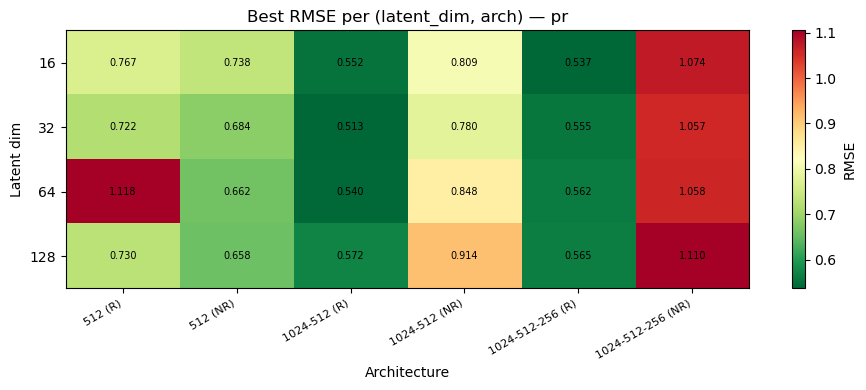

In [ ]:
# ── RMSE heatmap — latent_dim × architecture (best over dropout) ───
hidden_labels_ordered = ["512 (R)", "512 (NR)", "1024-512 (R)", "1024-512 (NR)",
                         "1024-512-256 (R)", "1024-512-256 (NR)"]
latent_dims = [16, 32, 64, 128]

# Build pivot: best RMSE per (latent_dim, arch_label)
pivot = ae_best.pivot(index="latent_dim", columns="arch_label", values="rmse")
pivot = pivot.reindex(index=latent_dims)

# Filter to only the columns that exist in the data
available_cols = [c for c in hidden_labels_ordered if c in pivot.columns]
pivot = pivot[available_cols]

fig, ax = plt.subplots(figsize=(len(available_cols) * 1.4 + 1, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r",
               vmin=np.nanpercentile(pivot.values, 5),
               vmax=np.nanpercentile(pivot.values, 95))
plt.colorbar(im, ax=ax, label="RMSE")

ax.set_xticks(range(len(available_cols)))
ax.set_xticklabels(available_cols, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(latent_dims)))
ax.set_yticklabels(latent_dims)
ax.set_xlabel("Architecture")
ax.set_ylabel("Latent dim")
ax.set_title(f"Best RMSE per (latent_dim, arch) — {NOTEBOOK_VAR}")

for i in range(len(latent_dims)):
    for j in range(len(available_cols)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7)

fig.tight_layout()
plt.show()

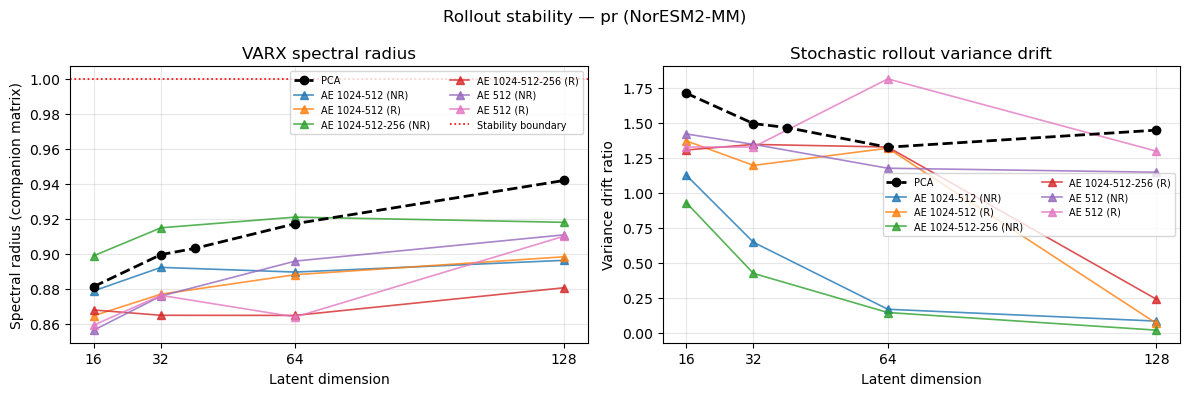

In [ ]:
# ── Rollout stability — spectral radius & variance drift ────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel, title in zip(
    axes,
    ["spectral_radius", "variance_drift_ratio"],
    ["Spectral radius (companion matrix)", "Variance drift ratio"],
    ["VARX spectral radius", "Stochastic rollout variance drift"],
):
    # PCA
    ax.plot(pca_best["latent_dim"], pca_best[metric], "o--",
            color="black", label="PCA", linewidth=2, zorder=3)
    # AE (best)
    for col, arch in zip(colors, arch_labels):
        sub = ae_best[ae_best["arch_label"] == arch].sort_values("latent_dim")
        ax.plot(sub["latent_dim"], sub[metric], marker="^", color=col,
                label=f"AE {arch}", linewidth=1.2, alpha=0.8)

    if metric == "spectral_radius":
        ax.axhline(1.0, color="red", linestyle=":", linewidth=1.2, label="Stability boundary")

    ax.set_xlabel("Latent dimension")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks([16, 32, 64, 128])
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Rollout stability — {NOTEBOOK_VAR} ({MODEL})", fontsize=12)
fig.tight_layout()
plt.show()

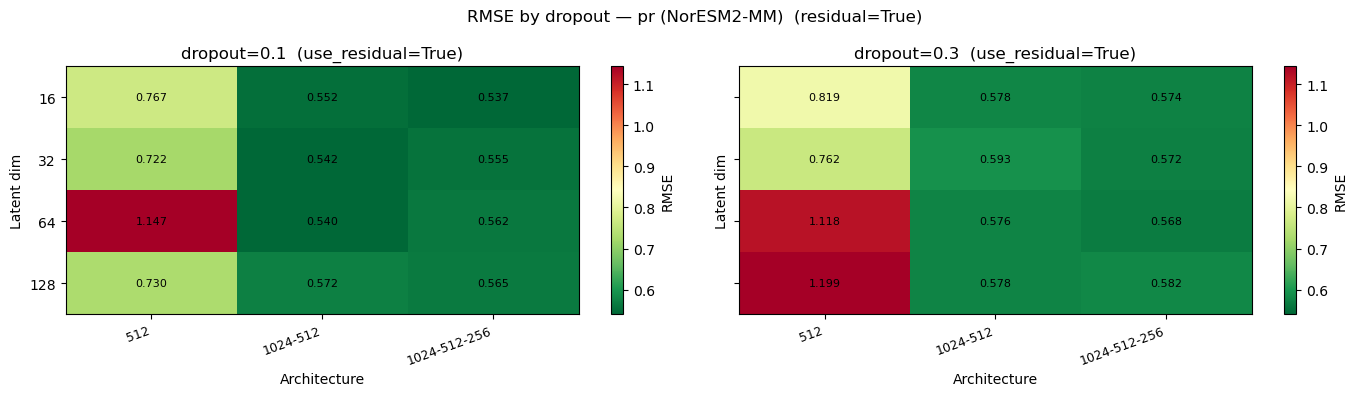

Mean RMSE (residual=True, dropout=0.1): 0.6494
Mean RMSE (residual=True, dropout=0.3): 0.7100


In [ ]:
# ── Dropout comparison heatmap: 0.1 vs 0.3 (residual=True only) ─────────
df_ae_loaded['h_str'] = df_ae_loaded['hidden'].apply(
    lambda h: '-'.join(str(int(x)) for x in h))

hidden_order = ['512', '1024-512', '1024-512-256']
latent_dims  = [16, 32, 64, 128]

vmin_do = df_ae_loaded[df_ae_loaded['use_residual']]['rmse'].quantile(0.05)
vmax_do = df_ae_loaded[df_ae_loaded['use_residual']]['rmse'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, do_val in zip(axes, [0.1, 0.3]):
    sub = df_ae_loaded[(df_ae_loaded['dropout'] == do_val) & df_ae_loaded['use_residual']]
    pivot = sub.pivot_table(index='latent_dim', columns='h_str',
                            values='rmse', aggfunc='min')
    pivot = pivot.reindex(index=latent_dims)
    avail = [c for c in hidden_order if c in pivot.columns]
    pivot = pivot[avail]

    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                   vmin=vmin_do, vmax=vmax_do)
    plt.colorbar(im, ax=ax, label='RMSE')
    ax.set_xticks(range(len(avail)))
    ax.set_xticklabels(avail, rotation=20, ha='right', fontsize=9)
    ax.set_yticks(range(len(latent_dims)))
    ax.set_yticklabels(latent_dims)
    ax.set_xlabel('Architecture'); ax.set_ylabel('Latent dim')
    ax.set_title(f'dropout={do_val}  (use_residual=True)')
    for i in range(len(latent_dims)):
        for j in range(len(avail)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8)

fig.suptitle(f'RMSE by dropout — {NOTEBOOK_VAR} ({MODEL})  (residual=True)', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'phase4_dropout_heatmap.png', dpi=150)
plt.show()

for do_val in [0.1, 0.3]:
    m = df_ae_loaded[(df_ae_loaded['dropout']==do_val) & df_ae_loaded['use_residual']]['rmse'].mean()
    print(f'Mean RMSE (residual=True, dropout={do_val}): {m:.4f}')


From the figures we can conclude on some things:
* AE > PCA - much better RMSE
    * The linear PCA baseline (black dashed) steadily improves as capacity increases, but it never matches the accuracy of the best-performing deep residual autoencoders.
* wider architecture for the encoder-decoder seems to be benefitial (as opposed to only one layer) and residual blocks drives the rmse down for these. **residual blocks should be included**
* The RMSE of the AE model is more driven by the architecture than the latent dimension size (contrasting the behaviour seen for PCA based modelling)
* All AE's seem to be stable and safe to use for rollout. Variance is driven to very low values when latent dim is 128 which is not wanted.
* using **dropout at 0.1** is giving better rmse than 0.3 - perhaps it is introducing to much noise.


In [ ]:
# ── top-10 AE configs by RMSE, annotated with stability ─────────────
cols_show = [
    "latent_dim", "arch_label", "dropout", "use_residual",
    "rmse", "explained_variance", "spectral_radius",
    "variance_drift_ratio", "nan_fraction", "train_time_s",
]
cols_show = [c for c in cols_show if c in df_ae_loaded.columns]

top10 = (
    df_ae_loaded[cols_show]
    .sort_values("rmse")
    .head(10)
    .reset_index(drop=True)
)
print("Top-10 AE configs by RMSE:")
print(top10.to_string())

# Best PCA for reference
pca_ref_cols = [c for c in ["n_modes", "rmse", "explained_variance",
                              "spectral_radius", "variance_drift_ratio"] if c in df_pca_loaded.columns]
print("\nPCA baseline:")
print(df_pca_loaded[pca_ref_cols].to_string(index=False))

Top-10 AE configs by RMSE:
   latent_dim        arch_label  dropout  use_residual  rmse  explained_variance  spectral_radius  variance_drift_ratio  nan_fraction  train_time_s
0          16  1024-512-256 (R)    0.100          True 0.537               0.788            0.868                 1.326         0.000        76.068
1          64      1024-512 (R)    0.100          True 0.540               0.785            0.886                 1.309         0.000        81.412
2          32      1024-512 (R)    0.100          True 0.542               0.783            0.882                 1.261         0.000        71.328
3          16      1024-512 (R)    0.100          True 0.552               0.776            0.867                 1.397         0.000        77.195
4          32  1024-512-256 (R)    0.100          True 0.555               0.773            0.864                 1.384         0.000        88.935
5          64  1024-512-256 (R)    0.100          True 0.562               0.768     

In [ ]:
# ── Latent-space diagnostics table (residual=True, dropout=0.1) ───────────────────────
diag_cols = [
    'latent_dim', 'h_str', 'dropout', 'rmse',
    'effective_rank', 'mean_acf_lag1', 'mean_acf_lag12',
    'mean_skew', 'mean_kurt', 'corr_matrix_offdiag_mean',
    'ks_normality_mean_pval', 'ljungbox_mean_pval',
]
diag_cols = [c for c in diag_cols if c in df_ae_loaded.columns]

diag_df = (
    df_ae_loaded[df_ae_loaded['use_residual'] & (df_ae_loaded['dropout'] == 0.1)]
    .sort_values("rmse")
    [diag_cols]
    .reset_index(drop=True)
)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_rows', None)
print('Latent-space diagnostics (residual=True, dropout=0.1):')
print(diag_df.to_string(index=False))


Latent-space diagnostics (residual=True, dropout=0.1):
 latent_dim        h_str  dropout  rmse  effective_rank  mean_acf_lag1  mean_acf_lag12  mean_skew  mean_kurt  corr_matrix_offdiag_mean  ks_normality_mean_pval  ljungbox_mean_pval
         16 1024-512-256    0.100 0.537          14.718          0.339           0.184      0.036      0.427                     0.080                   0.081               0.191
         64     1024-512    0.100 0.540          49.517          0.226           0.097     -0.008      0.246                     0.066                   0.653               0.530
         32     1024-512    0.100 0.542          29.443          0.265           0.118      0.013      0.189                     0.058                   0.582               0.138
         16     1024-512    0.100 0.552          15.063          0.354           0.161      0.028      0.579                     0.072                   0.021               0.232
         32 1024-512-256    0.100 0.555          2

---
Top-5 Model Contrast

Before committing to one config for further tuning we load all top-5 sweep candidates and compare them across **five complementary axes**:

| Axis | Why it matters |
|---|---|
| Reconstruction RMSE / EV | How well the AE compresses spatial structure |
| Spectral radius | Whether the VARX is stable over long rollouts |
| Variance drift ratio | Whether stochastic rollouts blow up / collapse |
| Effective latent rank | Are all latent dimensions actually used? |
| Training cost | Practical concern for MeteorInterface re-training |

In [ ]:
N_TOP = 5
top5_rows = df_ae_loaded.sort_values('rmse').head(N_TOP).reset_index(drop=True)

n_lat_p3b, n_lon_p3b = len(lats), len(lons)
top5_reconstructions = []   # list of (T, n_lat*n_lon) arrays
top5_missing_ckpt    = []   # indices where checkpoint was not found

for rank, row in top5_rows.iterrows():
    cfg = dict(
        latent_dim  = int(row['latent_dim']),
        hidden      = [int(h) for h in row['hidden']],
        dropout     = float(row['dropout']),
        use_residual= bool(row['use_residual']),
        epochs      = int(row['epochs']),
        device      = 'auto',
    )
    # Phase 6 rows carry extra keys — include them only if present
    for extra_key in ('activation', 'optimizer', 'loss', 'lr', 'weight_decay'):
        if extra_key in row and pd.notna(row[extra_key]):
            cfg[extra_key] = row[extra_key]

    cid  = _reg.config_id(cfg)
    ckpt = SCRATCH_DIR / 'checkpoints' / f'ae_{cid}.pt'

    if not ckpt.exists():
        print(f'  [rank {rank}] ⚠ checkpoint missing: {ckpt.name}')
        top5_reconstructions.append(None)
        top5_missing_ckpt.append(rank)
        continue

    ae_m = ConfigurableMLP(
        input_dim    = X_ae_mlp.shape[1],
        latent_dim   = cfg['latent_dim'],
        hidden       = tuple(cfg['hidden']),
        dropout      = cfg['dropout'],
        use_residual = cfg['use_residual'],
    )
    ae_m.load_state_dict(torch.load(ckpt, map_location='cpu', weights_only=True))
    ae_m.eval()
    X_recon = ae_m.decode(ae_m.encode(X_ae_mlp))   # (T, n_pixels), normalised
    top5_reconstructions.append(X_recon)

    rmse_val = float(np.sqrt(((X_recon - X_ae_mlp)**2).mean(axis=0)).mean())
    print(f'  rank {rank}  {row["arch_label"]:20s}  '
          f'latent={cfg["latent_dim"]:3d}  do={cfg["dropout"]:.1f}  '
          f'RMSE={rmse_val:.4f}  ckpt={ckpt.name[:20]}…')

print(f'\n✅ Loaded {N_TOP - len(top5_missing_ckpt)}/{N_TOP} top-5 checkpoints')
print('\nTop-5 overview:')
cols_brief = ['latent_dim', 'arch_label', 'dropout', 'use_residual',
              'rmse', 'explained_variance', 'spectral_radius',
              'variance_drift_ratio', 'effective_rank', 'train_time_s']
cols_brief = [c for c in cols_brief if c in top5_rows.columns]
print(top5_rows[cols_brief].to_string(index=True))


  rank 0  1024-512-256 (R)      latent= 16  do=0.1  RMSE=0.3897  ckpt=ae_6f254c5952a2.pt…
  rank 1  1024-512 (R)          latent= 64  do=0.1  RMSE=0.3927  ckpt=ae_d85f0bc5ba73.pt…
  rank 2  1024-512 (R)          latent= 32  do=0.1  RMSE=0.3937  ckpt=ae_197deb14bcdf.pt…
  rank 3  1024-512 (R)          latent= 16  do=0.1  RMSE=0.3997  ckpt=ae_2befa4d21d1f.pt…
  rank 4  1024-512-256 (R)      latent= 32  do=0.1  RMSE=0.4015  ckpt=ae_b8002e9df40b.pt…

✅ Loaded 5/5 top-5 checkpoints

Top-5 overview:
   latent_dim        arch_label  dropout  use_residual  rmse  explained_variance  spectral_radius  variance_drift_ratio  effective_rank  train_time_s
0          16  1024-512-256 (R)    0.100          True 0.537               0.788            0.868                 1.326          14.718        76.068
1          64      1024-512 (R)    0.100          True 0.540               0.785            0.886                 1.309          49.517        81.412
2          32      1024-512 (R)    0.100          T

In [ ]:
top5_rows["effective_rank/latent_dim"] = top5_rows["effective_rank"] / top5_rows["latent_dim"]

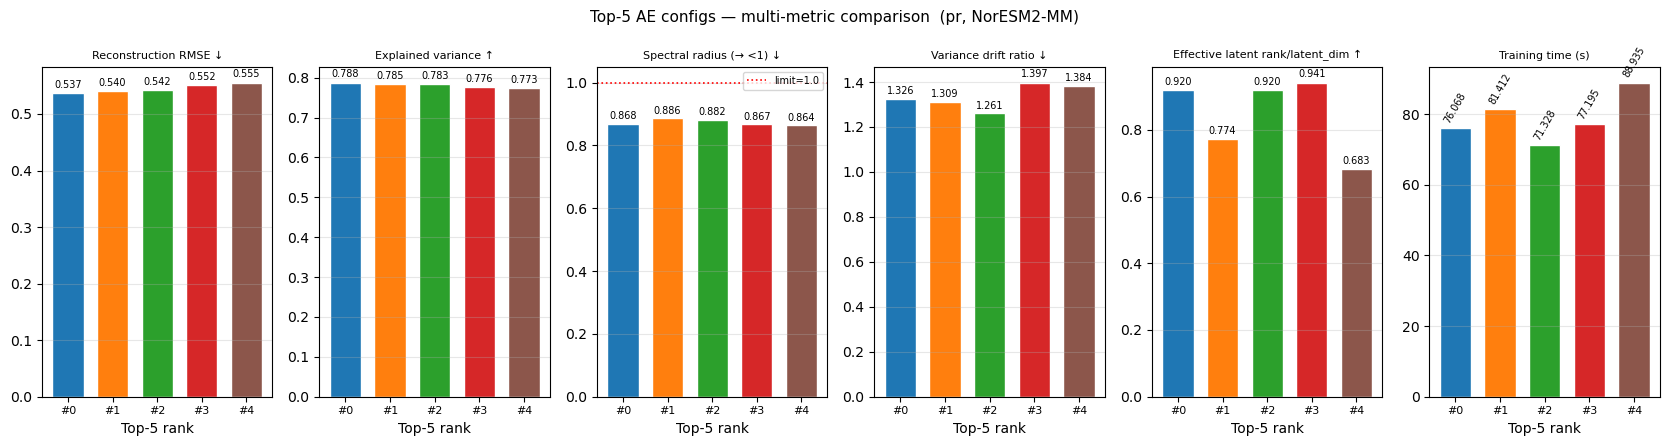

In [ ]:
_metric_spec = [
    ('rmse',                  'Reconstruction RMSE ↓',       'lower',   None),
    ('explained_variance',    'Explained variance ↑',        'higher',  None),
    ('spectral_radius',       'Spectral radius (→ <1) ↓',    'lower',   1.0),
    ('variance_drift_ratio',  'Variance drift ratio ↓',      'lower',   None),
    ('effective_rank/latent_dim',        'Effective latent rank/latent_dim ↑',     'higher',  None),
    ('train_time_s',          'Training time (s)',            'lower',   None),
]
_metric_spec = [(m, lbl, d, b) for m, lbl, d, b in _metric_spec
                if m in top5_rows.columns]

_colors = plt.cm.tab10(np.linspace(0, 0.5, N_TOP))
n_panels = len(_metric_spec)
fig, axes = plt.subplots(1, n_panels, figsize=(n_panels * 2.8, 4.5))

for ax, (metric, label, direction, boundary) in zip(axes, _metric_spec):
    vals = top5_rows[metric].values
    bars = ax.bar(np.arange(N_TOP), vals, color=_colors, edgecolor='white', width=0.7)

    if boundary is not None:
        ax.axhline(boundary, color='red', linestyle=':', linewidth=1.2,
                   label=f'limit={boundary}')

    # Add value labels
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if np.isfinite(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=7,
                    rotation=60 if metric == 'train_time_s' else 0)

    # Arrow to indicate preferred direction
    ax.set_title(label, fontsize=8)
    ax.set_xticks(np.arange(N_TOP))
    ax.set_xticklabels([f'#{i}' for i in range(N_TOP)], fontsize=8)
    ax.set_xlabel('Top-5 rank')
    ax.grid(True, axis='y', alpha=0.3)
    if boundary is not None:
        ax.legend(fontsize=7)

fig.suptitle(f'Top-5 AE configs — multi-metric comparison  ({NOTEBOOK_VAR}, {MODEL})',
             fontsize=11)
fig.tight_layout()
plt.show()

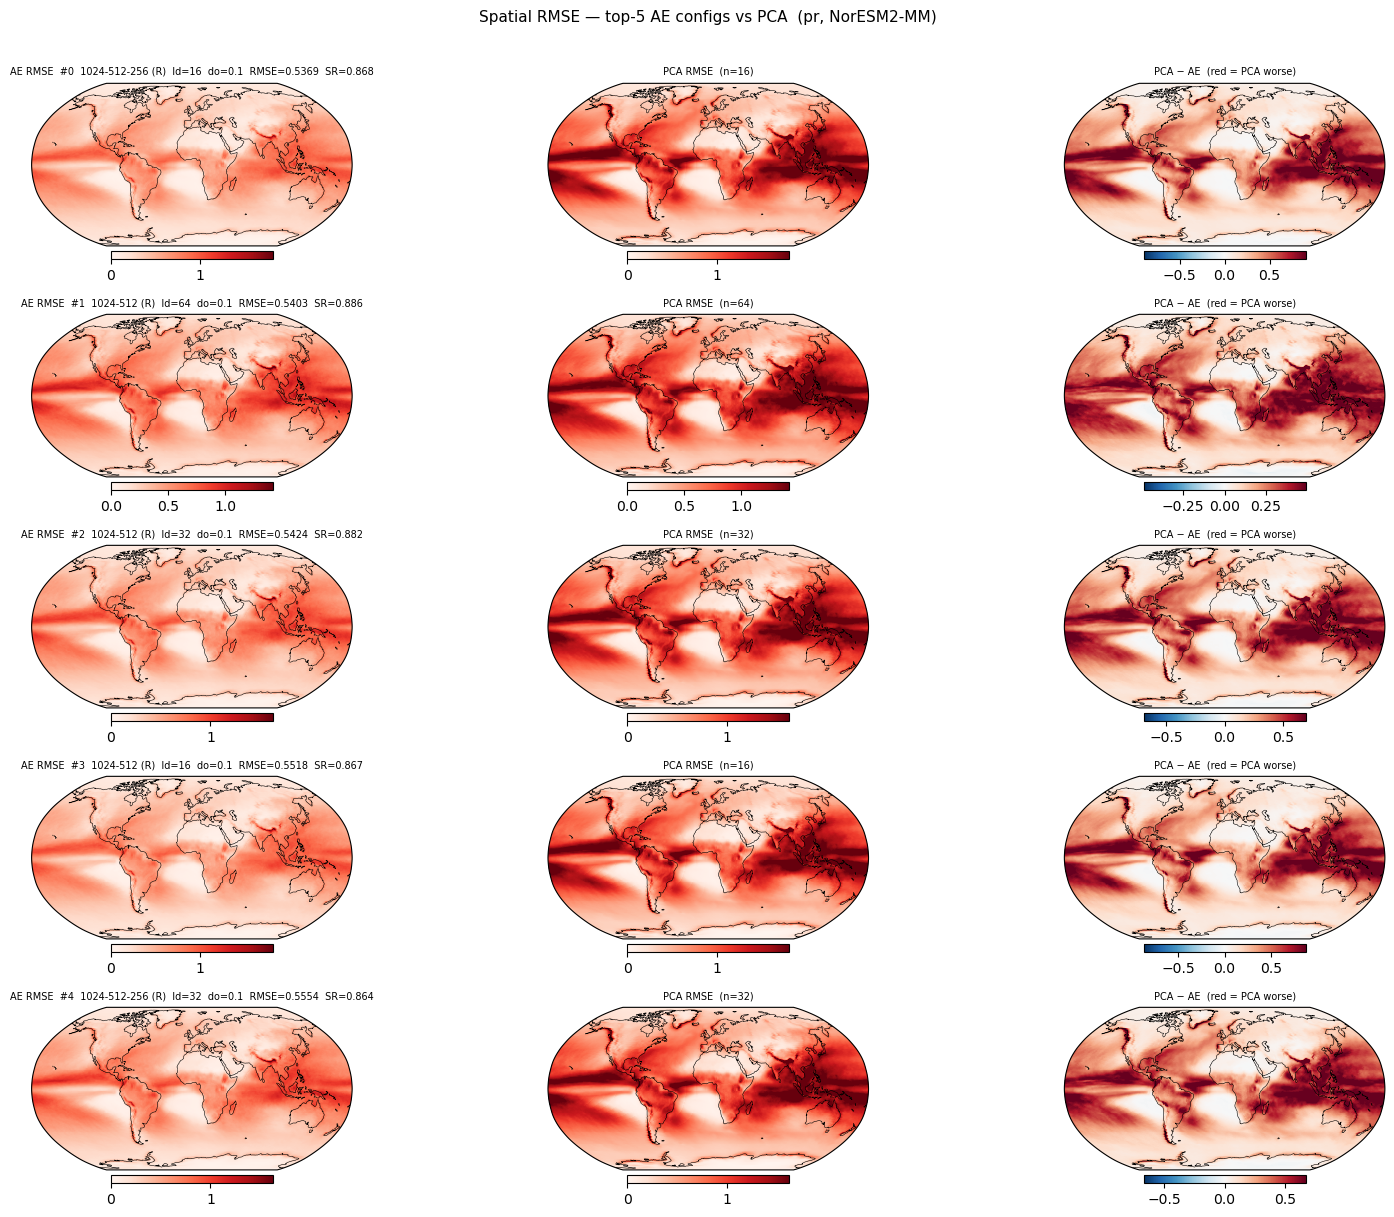

In [ ]:

# ── Spatial RMSE maps: all top-5 vs PCA at matched latent_dim ────────────────
def _mapax_p3b(ax, data, title, cmap, vmin, vmax):
    im = ax.pcolormesh(lons, lats, data.reshape(n_lat_p3b, n_lon_p3b),
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.set_title(title, fontsize=7)
    return im

# Pre-compute PCA reconstructions for unique latent dims in top-5
_unique_lds = top5_rows['latent_dim'].unique()
_pca_recons = {}
for ld in _unique_lds:
    _pca = SklearnPCA(n_components=int(ld), random_state=SEED)
    _pca_recons[int(ld)] = _pca.inverse_transform(_pca.fit_transform(X_ae_mlp))

# One row per top-5 config; columns: AE RMSE | PCA RMSE | AE−PCA difference
n_rows = N_TOP
n_cols = 3
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(n_cols * 5.5, n_rows * 2.4),
    subplot_kw={'projection': ccrs.Robinson()},
)

for rank in range(N_TOP):
    row_data   = top5_rows.loc[rank]
    ld         = int(row_data['latent_dim'])
    X_recon_ae = top5_reconstructions[rank]
    X_recon_pc = _pca_recons[ld]

    if X_recon_ae is None:
        for c in range(n_cols):
            axes[rank, c].set_title(f'#{rank} — checkpoint missing', fontsize=7)
        continue

    rmse_ae  = np.sqrt(((X_recon_ae - X_ae_mlp)**2).mean(axis=0))
    rmse_pca = np.sqrt(((X_recon_pc - X_ae_mlp)**2).mean(axis=0))
    diff     = rmse_pca - rmse_ae   # positive = PCA worse

    rmax = float(np.nanpercentile(np.maximum(rmse_ae, rmse_pca), 97))
    dmax = float(np.nanpercentile(np.abs(diff), 97))
    dmax = max(dmax, 1e-6)

    cfg_str = (f'#{rank}  {row_data["arch_label"]}  '
               f'ld={ld}  do={row_data["dropout"]:.1f}  '
               f'RMSE={row_data["rmse"]:.4f}  SR={row_data["spectral_radius"]:.3f}')

    im0 = _mapax_p3b(axes[rank, 0], rmse_ae,
                     f'AE RMSE  {cfg_str}', 'Reds', 0, rmax)
    im1 = _mapax_p3b(axes[rank, 1], rmse_pca,
                     f'PCA RMSE  (n={ld})', 'Reds', 0, rmax)
    im2 = _mapax_p3b(axes[rank, 2], diff,
                     'PCA − AE  (red = PCA worse)', 'RdBu_r', -dmax, dmax)

    for im, ax in [(im0, axes[rank, 0]), (im1, axes[rank, 1]), (im2, axes[rank, 2])]:
        plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.03, fraction=0.046)

fig.suptitle(f'Spatial RMSE — top-5 AE configs vs PCA  ({NOTEBOOK_VAR}, {MODEL})',
             fontsize=11, y=1.01)
fig.tight_layout()

plt.show()


In [ ]:
BEST_RANK = 2

best_row = top5_rows.loc[BEST_RANK].copy()

BEST_LD  = int(best_row['latent_dim'])
BEST_H   = [int(h) for h in best_row['hidden']]
BEST_DO  = float(best_row['dropout'])
BEST_RES = bool(best_row['use_residual'])
BEST_EP  = int(best_row['epochs'])

# Resolve checkpoint path (needed by Phase 4 for loading)
_best_cfg_for_ckpt = dict(
    latent_dim=BEST_LD, hidden=BEST_H,
    dropout=BEST_DO, use_residual=BEST_RES,
    epochs=BEST_EP, device='auto',
)
for _k in ('activation', 'optimizer', 'loss', 'lr', 'weight_decay'):
    if _k in best_row and pd.notna(best_row.get(_k)):
        _best_cfg_for_ckpt[_k] = best_row[_k]

_cid_sel  = _reg.config_id(_best_cfg_for_ckpt)
ckpt_best = SCRATCH_DIR / 'checkpoints' / f'ae_{_cid_sel}.pt'

print(f'Selected champion  (rank #{BEST_RANK})')
print(f'  Architecture : hidden={BEST_H}  latent_dim={BEST_LD}')
print(f'  Regularisation: dropout={BEST_DO}  use_residual={BEST_RES}')
print(f'  RMSE          : {best_row["rmse"]:.4f}')
print(f'  Spectral radius: {best_row["spectral_radius"]:.4f}')
print(f'  Variance drift : {best_row["variance_drift_ratio"]:.4f}')
print(f'  Checkpoint     : {ckpt_best}  exists={ckpt_best.exists()}')


Selected champion  (rank #2)
  Architecture : hidden=[1024, 512]  latent_dim=32
  Regularisation: dropout=0.1  use_residual=True
  RMSE          : 0.5424
  Spectral radius: 0.8822
  Variance drift : 1.2606
  Checkpoint     : /scratch/johannlf/ae_sweep/pr/checkpoints/ae_197deb14bcdf.pt  exists=True


---
## Best-Config Deep Dive

Spatial diagnostics and latent-space analysis for the sweep winner.
Also: side-by-side dropout=0.1 vs 0.3 heatmap.


In [ ]:

# ── Load selected champion checkpoint ─────────────────────────────────────────
# best_row / BEST_LD / BEST_H / BEST_DO / BEST_RES / BEST_EP / ckpt_best
# are all defined by the Phase 3b champion selection cell above.
import torch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from fys9429.ae_experiment_runner import ConfigurableMLP, ExperimentRegistry

print(f'Champion: latent_dim={BEST_LD}  hidden={BEST_H}  '
      f'dropout={BEST_DO}  residual={BEST_RES}')
print(f'  RMSE={best_row["rmse"]:.4f}  SR={best_row["spectral_radius"]:.4f}'
      f'  VDR={best_row["variance_drift_ratio"]:.4f}')

n_lat, n_lon = len(lats), len(lons)

# PCA at same latent dim for fair comparison
pca_p4 = SklearnPCA(n_components=40, random_state=SEED)
X_recon_pca_p4 = pca_p4.inverse_transform(pca_p4.fit_transform(X_ae_mlp))

print(f'\nCheckpoint: {ckpt_best.name}  exists={ckpt_best.exists()}')

ae_best_model = ConfigurableMLP(
    input_dim=X_ae_mlp.shape[1], latent_dim=BEST_LD,
    hidden=tuple(BEST_H), dropout=BEST_DO, use_residual=BEST_RES,
)
ae_best_model.load_state_dict(
    torch.load(ckpt_best, map_location='cpu', weights_only=True))
ae_best_model.eval()

X_recon_ae_p4 = ae_best_model.decode(ae_best_model.encode(X_ae_mlp))
pcs_best      = ae_best_model.encode(X_ae_mlp)   # kept for Phase 5

rmse_pca_p4 = np.sqrt(((X_recon_pca_p4 - X_ae_mlp)**2).mean(axis=0))
rmse_ae_p4  = np.sqrt(((X_recon_ae_p4  - X_ae_mlp)**2).mean(axis=0))

print(f'\nSpatial mean RMSE — PCA (n={BEST_LD}): {rmse_pca_p4.mean():.4f}')
print(f'Spatial mean RMSE — best AE:            {rmse_ae_p4.mean():.4f}')
print(f'Improvement: {(rmse_pca_p4.mean()-rmse_ae_p4.mean())/rmse_pca_p4.mean()*100:.1f}%')


NameError: name 'BEST_LD' is not defined

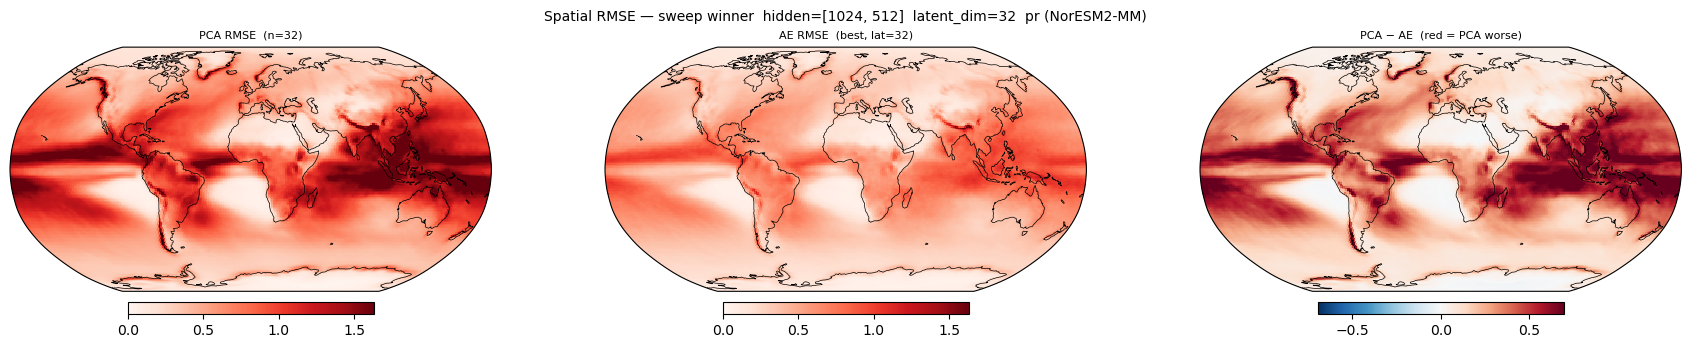

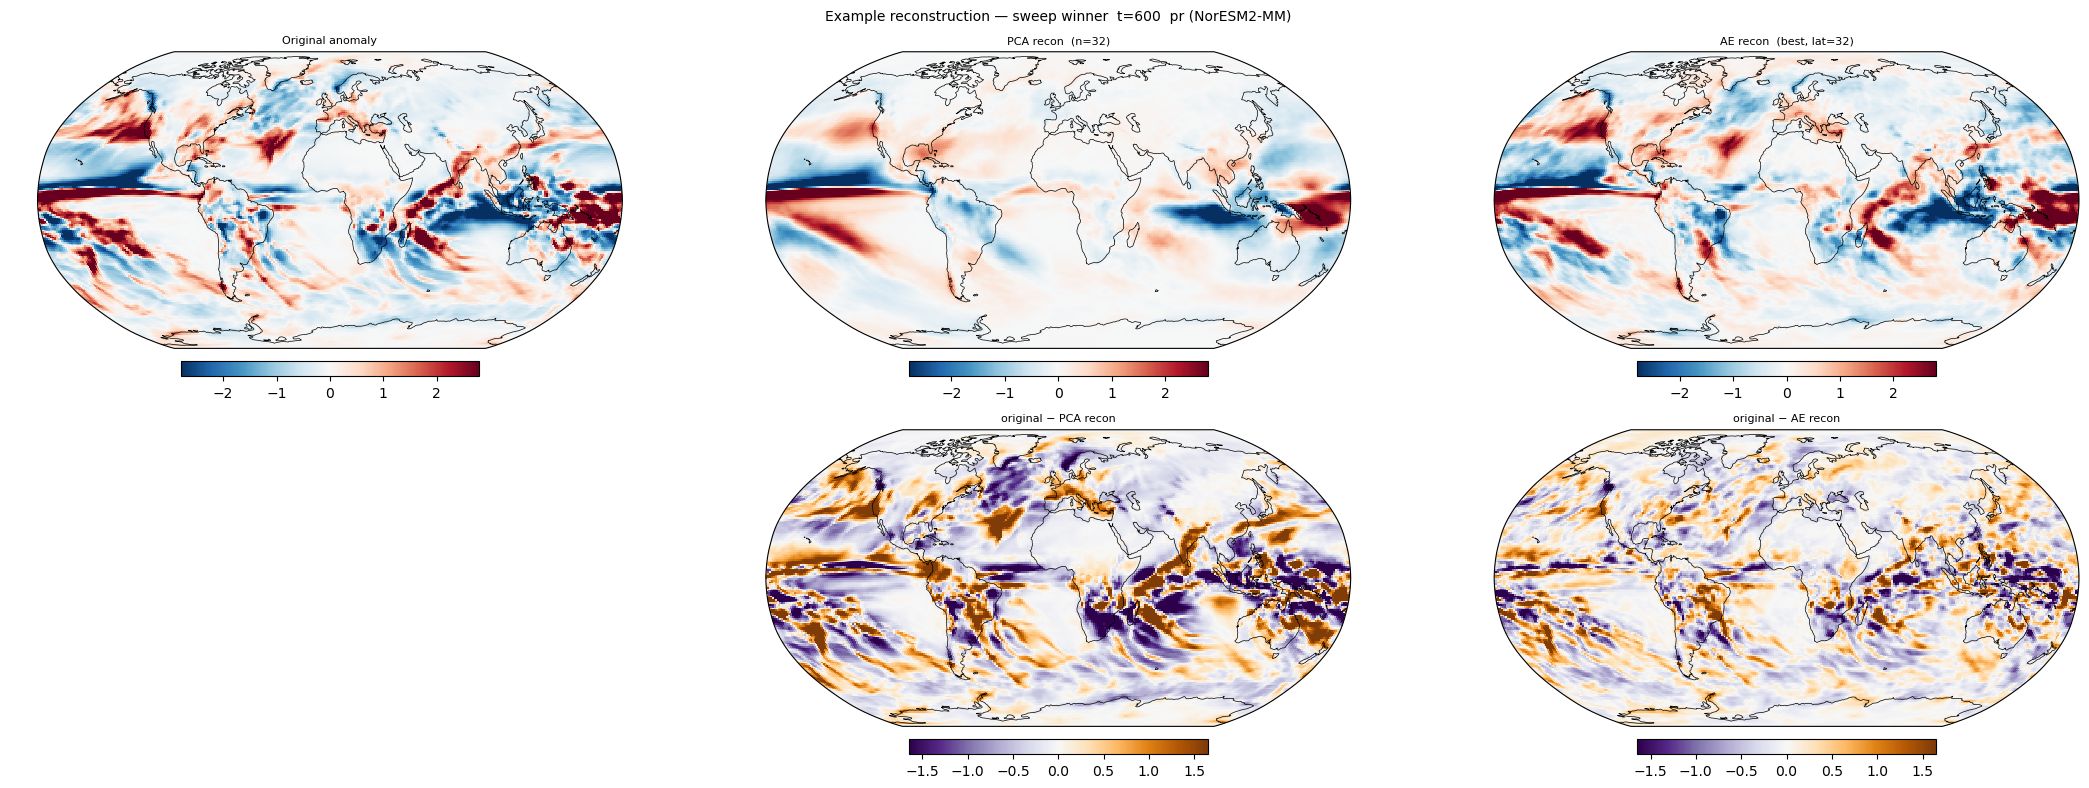

In [ ]:
# ── Spatial RMSE maps: sweep winner vs PCA ──────────────────────────────
def _mapax(ax, data, title, cmap, vmin, vmax):
    im = ax.pcolormesh(lons, lats, data.reshape(n_lat, n_lon), cmap=cmap,
                       vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=8)
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, fraction=0.046)

rmax = float(np.nanpercentile(np.maximum(rmse_pca_p4, rmse_ae_p4), 97))
dmax = float(np.nanpercentile(np.abs(rmse_pca_p4 - rmse_ae_p4), 97))

fig, axes = plt.subplots(1, 3, figsize=(18, 3.5),
                          subplot_kw={'projection': ccrs.Robinson()})
_mapax(axes[0], rmse_pca_p4,              f'PCA RMSE  (n={BEST_LD})',         'Reds',   0,     rmax)
_mapax(axes[1], rmse_ae_p4,               f'AE RMSE  (best, lat={BEST_LD})',  'Reds',   0,     rmax)
_mapax(axes[2], rmse_pca_p4 - rmse_ae_p4, 'PCA − AE  (red = PCA worse)',     'RdBu_r', -dmax, dmax)
fig.suptitle(f'Spatial RMSE — sweep winner  hidden={BEST_H}  '
             f'latent_dim={BEST_LD}  {NOTEBOOK_VAR} ({MODEL})', fontsize=10)
fig.tight_layout()
plt.show()

# ── Example time-step reconstruction ────────────────────────────────────────
T_SAMPLE = 600
orig_map      = X_ae_mlp[T_SAMPLE].reshape(n_lat, n_lon)
recon_pca_map = X_recon_pca_p4[T_SAMPLE].reshape(n_lat, n_lon)
recon_ae_map  = X_recon_ae_p4[T_SAMPLE].reshape(n_lat, n_lon)

v  = float(np.nanpercentile(np.abs(orig_map), 97))
dv = float(np.nanpercentile(np.abs(recon_ae_map - recon_pca_map), 97))

fig, axes = plt.subplots(2, 3, figsize=(22, 8),
                          subplot_kw={'projection': ccrs.Robinson()})
axes[1, 0].axis('off')
_mapax(axes[0, 0], orig_map,      'Original anomaly',                 'RdBu_r', -v,  v)
_mapax(axes[0, 1], recon_pca_map, f'PCA recon  (n={BEST_LD})',        'RdBu_r', -v,  v)
_mapax(axes[0, 2], recon_ae_map,  f'AE recon  (best, lat={BEST_LD})', 'RdBu_r', -v,  v)
_mapax(axes[1, 1], orig_map - recon_pca_map, 'original − PCA recon',  'PuOr_r', -dv, dv)
_mapax(axes[1, 2], orig_map - recon_ae_map, 'original − AE recon', 'PuOr_r', -dv, dv)

fig.suptitle(f'Example reconstruction — sweep winner  t={T_SAMPLE}  '
             f'{NOTEBOOK_VAR} ({MODEL})', fontsize=10)
fig.tight_layout()
plt.show()


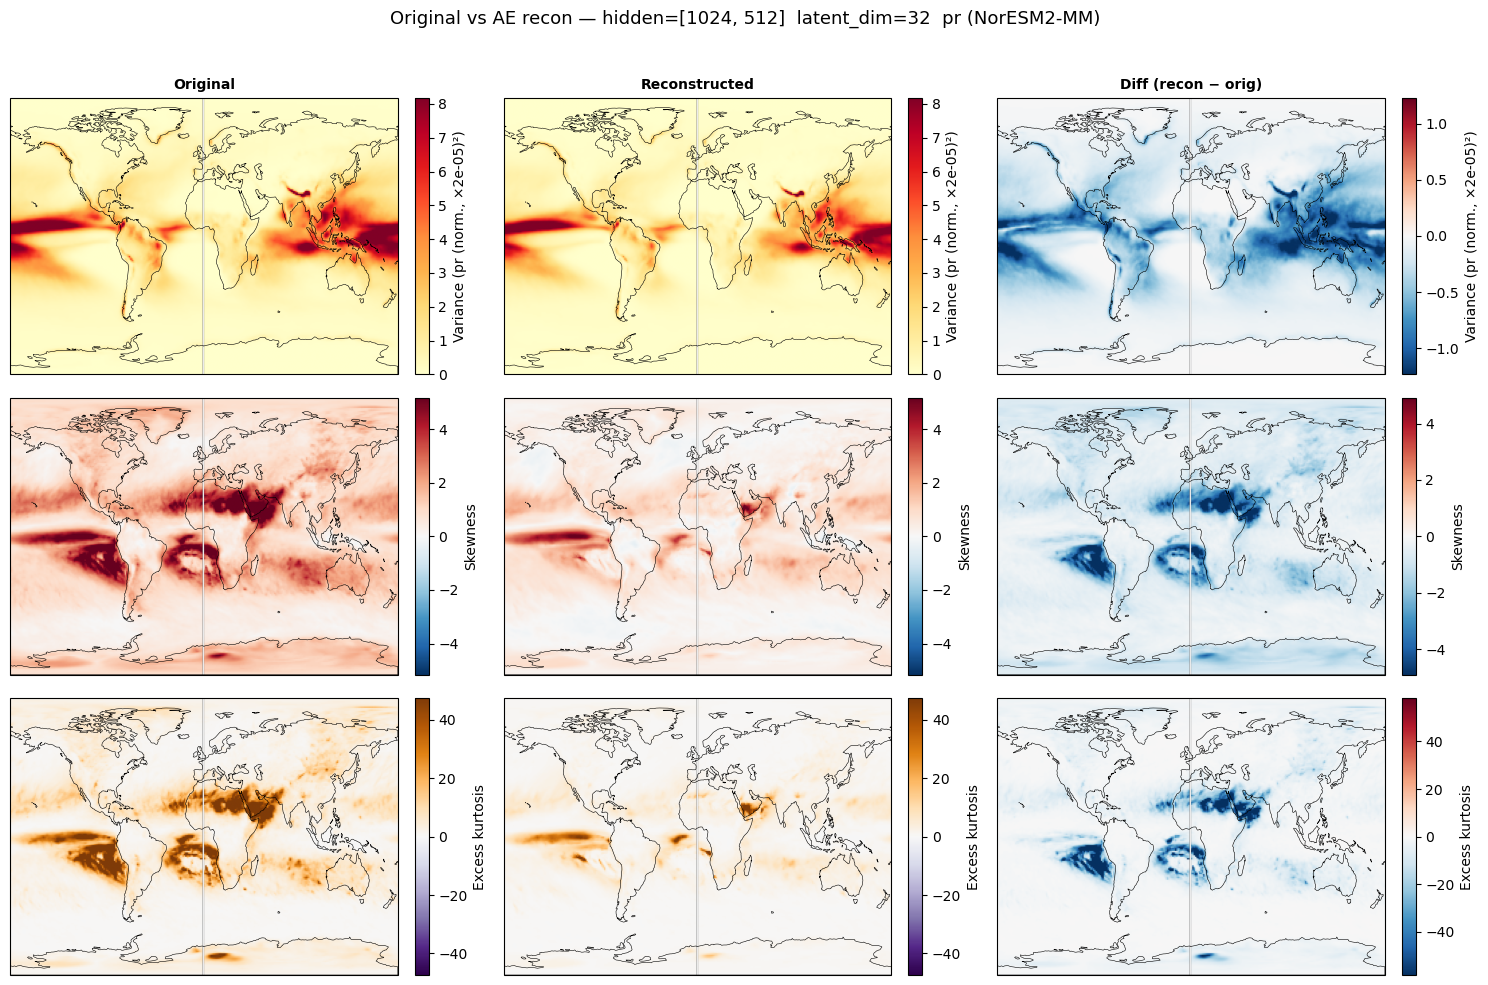

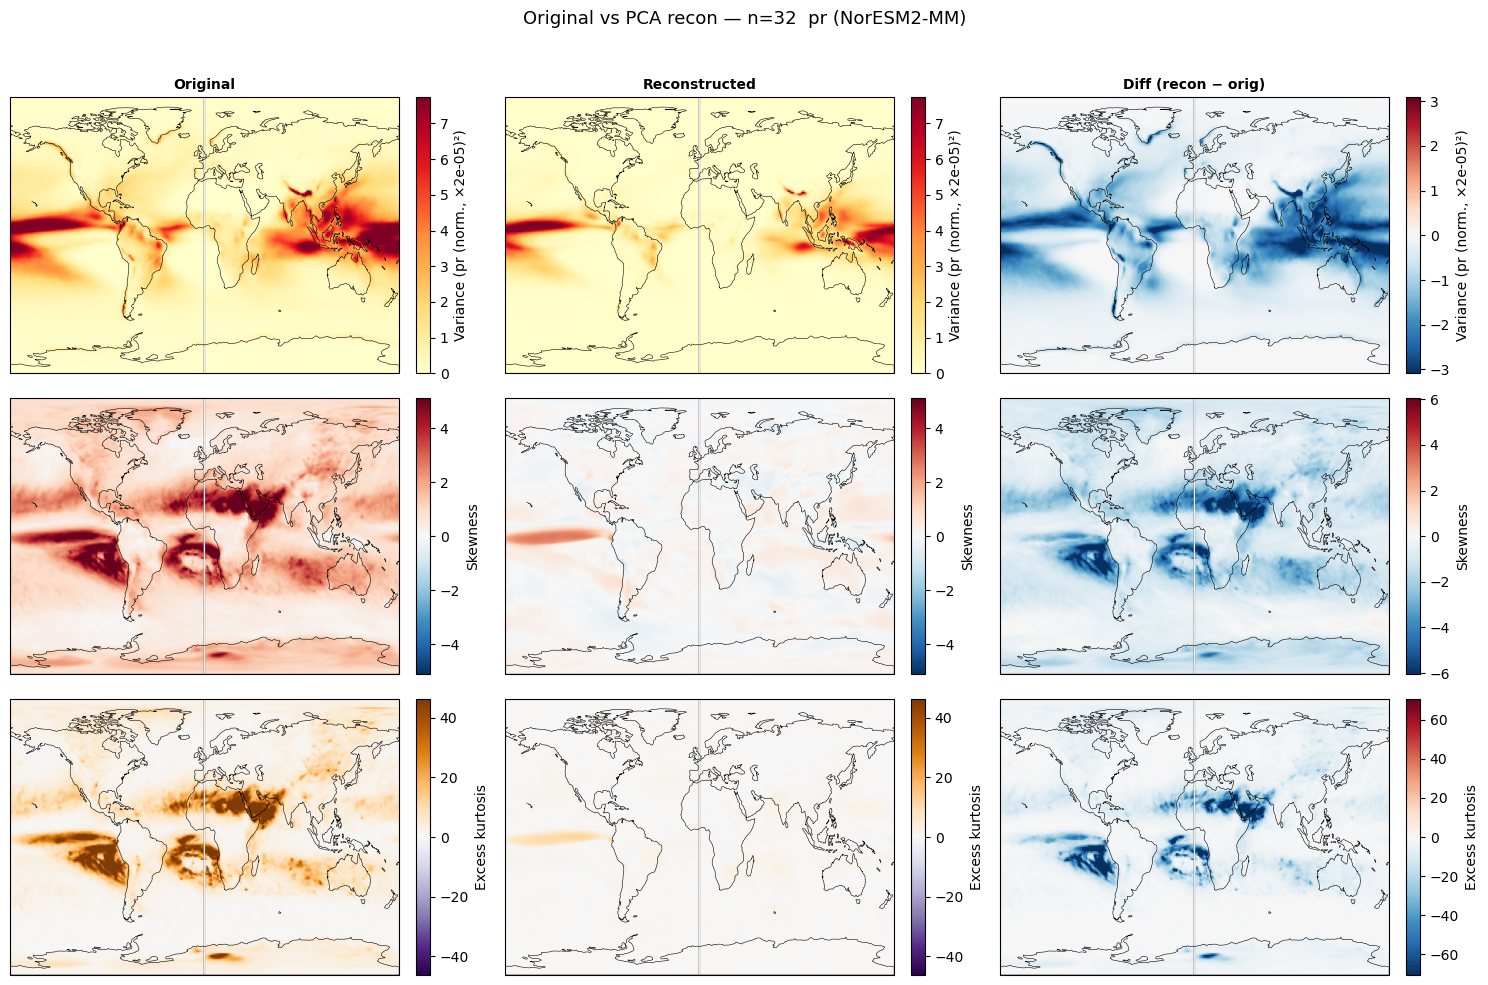

Metric              AE       PCA    AE better?
--------------------------------------------
var_mae         0.3242    0.8142           yes
skew_mae        0.8596    1.3782           yes
kurt_mae        5.8190    7.8321           yes


In [ ]:
# ── Higher-order statistics: original vs best-AE vs PCA reconstruction ───────
from fys9429.ae_diagnostics import compare_field_statistics

extent = [float(lons.min()), float(lons.max()),
          float(lats.min()), float(lats.max())]

# Reshape MLP format (T, n_lat*n_lon) → conv format (T, 1, n_lat, n_lon)
def _mlp_to_conv(X):
    return X.reshape(-1, n_lat, n_lon)[:, np.newaxis, :, :]

# X_ae_mlp is already globally normalised (÷ X_ae_scale), so X_orig_conv is
# already in the same space as the AE/PCA reconstructions — no further scaling.
X_orig_conv   = _mlp_to_conv(X_ae_mlp)
X_ae_conv_p4  = _mlp_to_conv(X_recon_ae_p4)
X_pca_conv_p4 = _mlp_to_conv(X_recon_pca_p4)

units_label = f'{NOTEBOOK_VAR} (norm., ×{X_ae_scale:.0e})'

# ── AE reconstruction statistics ─────────────────────────────────────────────
stats_ae, fig_ae = compare_field_statistics(
    X_orig_conv, X_ae_conv_p4,
    lats, lons, extent,
    units=units_label,
    title=f'Original vs AE recon — hidden={BEST_H}  latent_dim={BEST_LD}  {NOTEBOOK_VAR} ({MODEL})',
)
fig_ae.savefig(FIGURE_DIR / 'phase4_field_stats_ae.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PCA reconstruction statistics ────────────────────────────────────────────
stats_pca, fig_pca = compare_field_statistics(
    X_orig_conv, X_pca_conv_p4,
    lats, lons, extent,
    units=units_label,
    title=f'Original vs PCA recon — n={BEST_LD}  {NOTEBOOK_VAR} ({MODEL})',
)
fig_pca.savefig(FIGURE_DIR / 'phase4_field_stats_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Preservation score summary ────────────────────────────────────────────────
print(f"{'Metric':<12}  {'AE':>8}  {'PCA':>8}  {'AE better?':>12}")
print('-' * 44)
for key in ['var_mae', 'skew_mae', 'kurt_mae']:
    ae_val  = stats_ae['preservation'][key]
    pca_val = stats_pca['preservation'][key]
    print(f"{key:<12}  {ae_val:8.4f}  {pca_val:8.4f}  "
          f"{'yes' if ae_val < pca_val else 'no':>12}")


In [ ]:
# ── Phase 5b: Normal vs Student-t residuals ─────────────────────────────
from scipy import stats

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    vr_best_lag = VAR(endog=pcs_best_np, exog=X_exog_none).fit(2)

resids = np.asarray(vr_best_lag.resid)   # (T - best_lag, BEST_LD)
n_show = min(8, BEST_LD)

tdist_records = []
for i in range(BEST_LD):
    r = resids[:, i]
    df_t, _, scale_t = stats.t.fit(r, floc=0)
    _, ks_p_norm = stats.kstest(r, 'norm', args=(r.mean(), r.std()))
    _, ks_p_t    = stats.kstest(r, 't',    args=(df_t, 0, scale_t))
    tdist_records.append(dict(dim=i, student_t_df=df_t, scale_t=scale_t,
                               ks_p_normal=ks_p_norm, ks_p_student_t=ks_p_t))

df_tdist = pd.DataFrame(tdist_records)
print('Student-t fit for VARX residuals (first 12 dims):')
print(df_tdist.head(12).to_string(index=False, float_format='{:.3f}'.format))
print(f'\nFraction rejected by Normal KS (p<0.05): '
      f'{(df_tdist["ks_p_normal"] < 0.05).mean():.1%}')
print(f'Median estimated Student-t df: {df_tdist["student_t_df"].median():.1f}')

# Q-Q plots
n_cols = n_show // 2
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 2.5, 5))
for i, ax in enumerate(axes.flat[:n_show]):
    stats.probplot(resids[:, i], dist='norm', plot=ax)
    ax.set_title(f'latent dim {i}', fontsize=8)
    ax.tick_params(labelsize=6)
fig.suptitle(f'Residual Q-Q (vs Normal) — {NOTEBOOK_VAR} best AE  lag={best_lag}',
             fontsize=10)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'phase5_residual_qq.png', dpi=150)
plt.show()

# Student-t df distribution
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(df_tdist['student_t_df'].clip(upper=50), bins=20,
        color='tab:blue', edgecolor='white')
ax.axvline(df_tdist['student_t_df'].median(), color='red', linestyle='--',
           label=f'median df = {df_tdist["student_t_df"].median():.1f}')
ax.set(xlabel='Estimated Student-t df (clipped at 50)', ylabel='Count',
       title=f'Residual tail heaviness — {NOTEBOOK_VAR}')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


NameError: name 'pcs_best_np' is not defined

In [ ]:

pca_best = df_pca_loaded.copy()
pca_best["latent_dim"] = pca_best["n_modes"]

In [ ]:
# ── Phase 5c: Champion model summary ────────────────────────────────────
import json as _json

norm_rejected = (df_tdist['ks_p_normal'] < 0.05).mean()
print('=' * 60)
print('CHAMPION MODEL SUMMARY')
print('=' * 60)
print(f'  Variable      : {NOTEBOOK_VAR}  ({MODEL})')
print(f'  Architecture  : hidden={BEST_H}  latent_dim={BEST_LD}')
print(f'  Regularisation: dropout={BEST_DO}  use_residual={BEST_RES}')
print(f'  Training      : epochs={BEST_EP}')
print()
print(f'  Reconstruction RMSE  : {best_row["rmse"]:.4f}')
print(f'  Explained variance   : {best_row["explained_variance"]:.4f}')
print(f'  Spectral radius      : {best_row["spectral_radius"]:.4f}')
print(f'  Variance drift ratio : {best_row["variance_drift_ratio"]:.4f}')
print(f'  NaN fraction         : {best_row["nan_fraction"]:.4f}')
print(f'  Median residual df   : {df_tdist["student_t_df"].median():.1f}  '
      f'(Gaussian rejected in {norm_rejected:.0%} of dims)')
print()
pca_ref = pca_best[pca_best['latent_dim'] == BEST_LD].iloc[0]
print(f'  PCA baseline (n={BEST_LD}) RMSE : {pca_ref["rmse"]:.4f}')
print(f'  AE improvement over PCA        : '
      f'{(pca_ref["rmse"]-best_row["rmse"])/pca_ref["rmse"]*100:.1f}%')
print('=' * 60)

champion = dict(
    variable=NOTEBOOK_VAR, model=MODEL,
    latent_dim=BEST_LD, hidden=BEST_H,
    dropout=BEST_DO, use_residual=BEST_RES, epochs=BEST_EP,
    varx_lag_order=best_lag, use_exog='none',
    noise_pc_distribution='student_t' if norm_rejected > 0.5 else 'normal',
    rmse=float(best_row['rmse']),
    spectral_radius=float(best_row['spectral_radius']),
    checkpoint=str(ckpt_best),
)
champion_path = SCRATCH_DIR / f'champion_{NOTEBOOK_VAR}.json'
champion_path.write_text(_json.dumps(champion, indent=2))
print(f'\n✅ Champion config saved → {champion_path}')


NameError: name 'df_tdist' is not defined

---
## Activation, Optimizer & Loss Ablation

One-at-a-time ablation starting from the first sweep winner.

- Activation function — 4 variants, all other hypers fixed
- Optimizer × Loss joint grid - the networks learning are stable and a higher one made it blow up (not shown here) so we keep that fixed


In [ ]:
# ── Phase 6a: Activation sweep ───────────────────────────────────────────────
act_grid = dict(
    latent_dim=[32],
    hidden=[[1024, 512]],
    dropout=[0.1],
    use_residual=[True],
    epochs=[50],
    device=['auto'],
    activation=['Hardswish', 'GELU', 'ReLU', 'SiLU'],
)

df_p6a_all = run_sweep(
    act_grid, X_ae_mlp, X_ae_conv,
    lats, lons, t_glob,
    results_dir=SCRATCH_DIR,
    lag_order=LAG_ORDER,
    use_exog='none',
    skip_done=True,
)

# Filter to: activation set, no optimizer key
_opt_col_6a = df_p6a_all.get('optimizer', pd.Series(np.nan, index=df_p6a_all.index))
df_p6a = df_p6a_all[df_p6a_all['activation'].notna() & _opt_col_6a.isna()].copy()

print(df_p6a[['activation', 'rmse', 'spectral_radius', 'variance_drift_ratio']]
      .sort_values('rmse').to_string(index=False))

BEST_ACT = df_p6a.sort_values('rmse').iloc[0]['activation']
print(f'\n→ Best activation: {BEST_ACT}')


[1/4] RUN   {'latent_dim': 32, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 50, 'device': 'auto', 'activation': 'Hardswish'}


       latent=32  hidden=[1024, 512]  dropout=0.1  residual=True  RMSE=0.5965  SR=0.8775  t=40s
[2/4] RUN   {'latent_dim': 32, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 50, 'device': 'auto', 'activation': 'GELU'}
       latent=32  hidden=[1024, 512]  dropout=0.1  residual=True  RMSE=0.5794  SR=0.8737  t=38s
[3/4] RUN   {'latent_dim': 32, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 50, 'device': 'auto', 'activation': 'ReLU'}
       latent=32  hidden=[1024, 512]  dropout=0.1  residual=True  RMSE=0.7812  SR=0.8741  t=37s
[4/4] RUN   {'latent_dim': 32, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 50, 'device': 'auto', 'activation': 'SiLU'}
       latent=32  hidden=[1024, 512]  dropout=0.1  residual=True  RMSE=0.5776  SR=0.8792  t=40s
activation  rmse  spectral_radius  variance_drift_ratio
      SiLU 0.578            0.879                 1.359
      GELU 0.579            0.874                 1.253
 Hardswish

In [ ]:
# ── Optimizer × Loss joint grid ────────────────────────────────────
# Fixes best activation; grid-searches optimizer, loss
optloss_grid = dict(
    latent_dim=[32],
    hidden=[[1024, 512]],
    dropout=[0.1],
    use_residual=[True],
    epochs=[100],
    device=['auto'],
    activation=[BEST_ACT],
    optimizer=['adamw', 'adam'],
    loss=['mse', 'mae', 'huber'],
    lr=[1e-3],
    weight_decay=[1e-5],
)

df_p6b_all = run_sweep(
    optloss_grid, X_ae_mlp, X_ae_conv,
    lats, lons, t_glob,
    results_dir=SCRATCH_DIR,
    lag_order=LAG_ORDER,
    use_exog='none',
    skip_done=True,
)

df_p6b = df_p6b_all[df_p6b_all['optimizer'].notna()].copy()

print(f'Phase 6b — {len(df_p6b)} configs')
print('\nMin RMSE by optimizer × loss (marginalised over lr, weight_decay):')
print(df_p6b.groupby(['optimizer', 'loss'])['rmse'].min().unstack().to_string())

best_row_6b = df_p6b.sort_values('rmse').iloc[0]
BEST_OPT  = best_row_6b['optimizer']
BEST_LOSS = best_row_6b['loss']
BEST_LR_6 = float(best_row_6b['lr'])
BEST_WD_6 = float(best_row_6b['weight_decay'])
print(f'\nBest: optimizer={BEST_OPT}  loss={BEST_LOSS}  '
      f'lr={BEST_LR_6:.0e}  wd={BEST_WD_6:.0e}  RMSE={best_row_6b["rmse"]:.4f}')


[1/6] RUN   {'latent_dim': 32, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'SiLU', 'optimizer': 'adamw', 'loss': 'mse', 'lr': 0.001, 'weight_decay': 1e-05}


       latent=32  hidden=[1024, 512]  dropout=0.1  residual=True  RMSE=0.5192  SR=0.8698  t=74s
[2/6] RUN   {'latent_dim': 32, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'SiLU', 'optimizer': 'adamw', 'loss': 'mae', 'lr': 0.001, 'weight_decay': 1e-05}
       latent=32  hidden=[1024, 512]  dropout=0.1  residual=True  RMSE=0.6813  SR=0.9009  t=89s
[3/6] RUN   {'latent_dim': 32, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'SiLU', 'optimizer': 'adamw', 'loss': 'huber', 'lr': 0.001, 'weight_decay': 1e-05}
       latent=32  hidden=[1024, 512]  dropout=0.1  residual=True  RMSE=0.5721  SR=0.8858  t=86s
[4/6] RUN   {'latent_dim': 32, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'SiLU', 'optimizer': 'adam', 'loss': 'mse', 'lr': 0.001, 'weight_decay': 1e-05}
       latent=32  hidden=[1024, 512]  dropout=0.1  

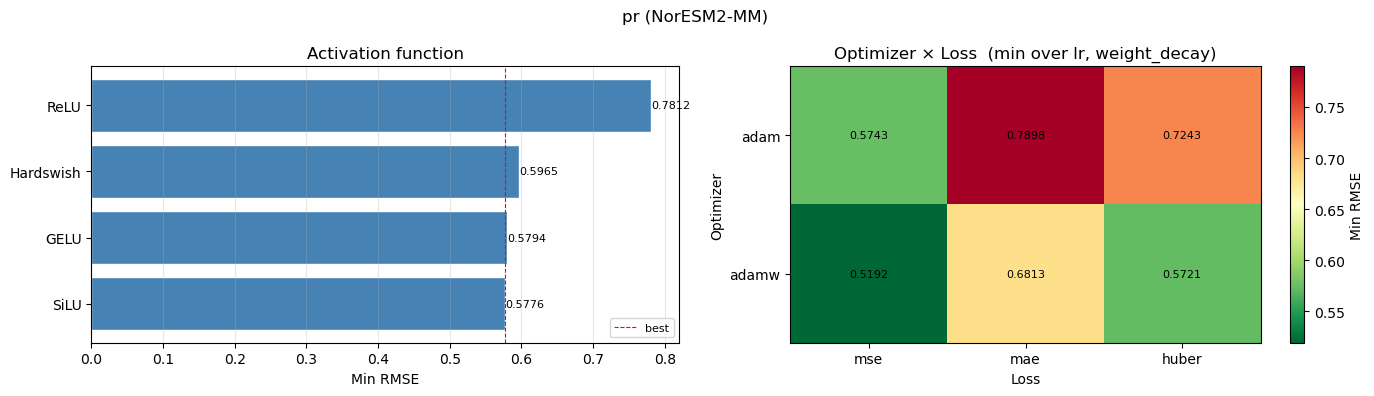

In [ ]:
# ── bar chart + heatmap ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: activation bar chart
act_rmse = df_p6a.groupby('activation')['rmse'].min().sort_values()
axes[0].barh(act_rmse.index, act_rmse.values, color='steelblue', edgecolor='white')
axes[0].axvline(act_rmse.min(), color='red', linestyle='--', lw=0.8, label='best')
for i, (name, val) in enumerate(act_rmse.items()):
    axes[0].text(val + 1e-4, i, f'{val:.4f}', va='center', fontsize=8)
axes[0].set(xlabel='Min RMSE', title='Activation function')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='x', alpha=0.3)

# Panel 2: optimizer × loss heatmap (min RMSE)
pivot = df_p6b.groupby(['optimizer', 'loss'])['rmse'].min().unstack('loss')
col_order = [c for c in ['mse', 'mae', 'huber'] if c in pivot.columns]
pivot = pivot[col_order]
vmin_h = pivot.values[np.isfinite(pivot.values)].min()
vmax_h = pivot.values[np.isfinite(pivot.values)].max()
im = axes[1].imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                    vmin=vmin_h, vmax=vmax_h)
plt.colorbar(im, ax=axes[1], label='Min RMSE')
axes[1].set_xticks(range(len(pivot.columns))); axes[1].set_xticklabels(pivot.columns)
axes[1].set_yticks(range(len(pivot.index)));   axes[1].set_yticklabels(pivot.index)
axes[1].set(xlabel='Loss', ylabel='Optimizer',
            title='Optimizer × Loss  (min over lr, weight_decay)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if np.isfinite(v):
            axes[1].text(j, i, f'{v:.4f}', ha='center', va='center', fontsize=8)

fig.suptitle(f'{NOTEBOOK_VAR} ({MODEL})', fontsize=12)
fig.tight_layout()
plt.show()


train the model to 100th epoch and compare

In [ ]:
best_model = dict(
    latent_dim=32,
    hidden=[1024, 512],
    dropout=0.1,
    use_residual=True,
    epochs=100,
    device='auto',
    activation=BEST_ACT,
    optimizer=BEST_OPT,
    loss=BEST_LOSS,
    lr=BEST_LR_6,
    weight_decay=BEST_WD_6,
)
results = run_ae_experiment(best_model, X_ae_mlp, X_ae_conv, lats, lons, t_glob,
                  lag_order=LAG_ORDER, use_exog='none', checkpoint_dir=SCRATCH_DIR)


{'rmse': 0.5465601482197552,
 'explained_variance': 0.7803066968920044,
 'spatial_corr': 0.8854380553603711,
 'arctic_rmse': 0.19129915535449982,
 'sh_rmse': 0.31516033411026,
 'skew_mae': 0.8000308871269226,
 'kurt_mae': 4.55164098739624,
 'effective_rank': 28.851715333147812,
 'mean_skew': -0.04383008927106857,
 'mean_kurt': 0.2591877281665802,
 'mean_acf_lag1': 0.2702011177316308,
 'mean_acf_lag12': 0.12038811738602817,
 'corr_matrix_offdiag_mean': 0.0627325111664169,
 'spectral_radius': 0.8742192506596368,
 'aic': 136.32569341262578,
 'bic': 140.47857259671392,
 'ljungbox_mean_pval': 0.4402892985986708,
 'ks_normality_mean_pval': 0.2571284557389518,
 'nan_fraction': 0.0,
 'inf_fraction': 0.0,
 'variance_drift_ratio': 1.3208879137063865,
 'mean_drift_abs': 0.11823485630474917,
 'train_time_s': 75.24622368812561}

In [ ]:
# ── best arch for pr ────────────────────────────────────────────────────
import json as _json

baseline_rmse = float(best_row['rmse'])  # Phase 2 sweep winner

print('=' * 60)
print('PHASE 6 WINNER SUMMARY')
print('=' * 60)
print(f'  Variable       : {NOTEBOOK_VAR}  ({MODEL})')
print(f'  Architecture   : hidden={BEST_H}  latent_dim={BEST_LD}')
print(f'  Best activation: {BEST_ACT}')
print(f'    → RMSE       : {df_p6a.sort_values("rmse").iloc[0]["rmse"]:.4f}')
print()
print(f'  Best optimizer : {BEST_OPT}')
print(f'  Best loss      : {BEST_LOSS}')
print(f'  Best lr        : {BEST_LR_6:.1e}')
print(f'  Best weight_decay: {BEST_WD_6:.1e}')
print(f'    → RMSE       : {best_row_6b["rmse"]:.4f}')
print()
p6_improvement = (baseline_rmse - best_row_6b['rmse']) / baseline_rmse * 100
print(f'  baseline RMSE : {baseline_rmse:.4f}')
print(f'  best RMSE     : {best_row_6b["rmse"]:.4f}')
print(f'  Improvement over before tuning activations, optimizer and loss : {p6_improvement:.2f}%')
print('=' * 60)

champion_p6 = dict(
    variable=NOTEBOOK_VAR, model=MODEL,
    latent_dim=BEST_LD, hidden=BEST_H,
    dropout=0.1, use_residual=True,
    activation=BEST_ACT,
    optimizer=BEST_OPT, loss=BEST_LOSS,
    lr=BEST_LR_6, weight_decay=BEST_WD_6,
    epochs=100,
    rmse_p2_baseline=baseline_rmse,
    rmse_p6_best=float(best_row_6b['rmse']),
    p6_improvement_pct=round(p6_improvement, 3),
)
champion_p6_path = SCRATCH_DIR / f'champion_p6_{NOTEBOOK_VAR}.json'
champion_p6_path.write_text(_json.dumps(champion_p6, indent=2))
print(f'\nChampion config saved -> {champion_p6_path}')


PHASE 6 WINNER SUMMARY
  Variable       : pr  (NorESM2-MM)
  Architecture   : hidden=[1024, 512]  latent_dim=32
  Best activation: SiLU
    → RMSE       : 0.5776

  Best optimizer : adamw
  Best loss      : mse
  Best lr        : 1.0e-03
  Best weight_decay: 1.0e-05
    → RMSE       : 0.5192

  baseline RMSE : 0.5424
  best RMSE     : 0.5192
  Improvement over before tuning activations, optimizer and loss : 4.27%

Champion config saved -> /scratch/johannlf/ae_sweep/pr/champion_p6_pr.json
